# Cooldown 3
### Implanted CaF2, Unannealed in Confocal with Mango

In [138]:
## General purpose
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.axes as axes
import scipy as sp
import scipy.fft
import drivers.spectroscopyHelpers as sh
import drivers3.laserHelpers as lh
import scipy.optimize as sp
import os
import time
import datetime
import scipy.signal
import matplotlib.colors as cls
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)
import importlib
import pprint
from tqdm import tqdm
import glob
import re
from scipy import stats
import qcodes as qc
import sys
import qil_Visa.visa as visa
import pyvisa

In [139]:
# Import functions!!
import drivers.spectroscopyHelpers as sh
import drivers.pulse_sequence as beeps
import drivers.proHelpers as proHelp
from drivers.dlccontrol import dlccontrol as ctrl
import drivers3.laserHelpers as lhzz
import drivers.experimentFunctions as exhp

In [140]:
### Toptica Laser
from toptica.lasersdk.dlcpro.v2_2_0 import DLCpro, NetworkConnection  
laserIP = '10.196.50.22'

### Wavemeter
from qil_WS6wavemeter import TCP_Wavemeter
try:
    wm = TCP_Wavemeter.cWS6WavemeterClient(host='qil-wario')
    print("Wavemeter frequency: ", wm.readFrequency())
except KeyError:
    print("Key error returned - wavemeter probably not seeing enough light.")

### Stahl power supply
from qcodes.instrument_drivers.rigol import DP832
from qcodes.instrument_drivers.stahl import Stahl
stahl = Stahl("stahl-9", "ASRL4")       
detectorOut = stahl.channel8

### American magnetics power supply
from qcodes.instrument_drivers.american_magnetics.AMI430_visa import AMI430 

### Moku AWG
import moku

### For the Moku Pro
from moku.instruments import ArbitraryWaveformGenerator
mokuIP = '10.196.50.45' # Sydnet6 IP for Moku Pro
awg = ArbitraryWaveformGenerator(mokuIP, force_connect=True, persist_state=True, read_timeout=30)

### For Bluey
import json 
import requests

### Attocube
import qil_attocube
amc = qil_attocube.Device('10.196.50.26')
amc.connect()
axis = 0 # Corresponds to axis 1 on the AMC300 controller

### Keithley DMM
import qcodes.instrument_drivers.tektronix.Keithley_6500 as dmm6500
dmm = dmm6500.Keithley_6500('dmm','TCPIP::10.196.50.27::INSTR')

### Rigol oscilloscope 
from qil_Rigol.rigol import cRigol 
scope = cRigol('10.196.50.21') # IP address of Rigol MSO5104 on the magnet rack is: 10.196.50.21. verify connection here.

Importing Functions
Wavemeter frequency:  193.7317352294922


c:\Users\Mario\.conda\envs\qcodes_env\lib\site-packages\qcodes\instrument\instrument_base.py:642: UserWarning: Changed stahl-9 to stahl_9 for instrument identifier
  warnings.warn(f"Changed {name} to {new_name} for instrument identifier")
[stahl_9(Stahl)] Could not connect at ASRL4
Traceback (most recent call last):
  File "c:\Users\Mario\.conda\envs\qcodes_env\lib\site-packages\qcodes\instrument\visa.py", line 215, in _connect_and_handle_error
    visa_handle, visabackend, resource_manager = self._open_resource(
  File "c:\Users\Mario\.conda\envs\qcodes_env\lib\site-packages\qcodes\instrument\visa.py", line 243, in _open_resource
    resource = resource_manager.open_resource(address)
  File "c:\Users\Mario\.conda\envs\qcodes_env\lib\site-packages\pyvisa\highlevel.py", line 3304, in open_resource
    res.open(access_mode, open_timeout)
  File "c:\Users\Mario\.conda\envs\qcodes_env\lib\site-packages\pyvisa\resources\resource.py", line 297, in open
    self.session, status = self._resour

VisaIOError: VI_ERROR_RSRC_BUSY (-1073807246): The resource is valid, but VISA cannot currently access it.

In [4]:
### Swabian timetagger
import TimeTagger
tt = TimeTagger.createTimeTagger()

# Setting up time-tagger histogram channel
# Parameters taken from 20251015 flashy country.ipynb 
ps = 1e12 # [ps/s] - picoseconds per second. As usual I try to frame variables in SI units, but Swabian is in picoseconds. :((
binwidth = 500e-9 * ps  # 0.1 ms, in picoseconds - [s] * [ps/s]
n_bins = 80 # number of bins

hist = TimeTagger.Histogram(tagger=tt, start_channel=2, click_channel=1, binwidth=binwidth, n_bins = n_bins)
tt.setTriggerLevel(2, 0.25)      # starts channel trigger level = 250 mV (signal is 500 mV)
tt.setTriggerLevel(1, 0.03)      # click channel trigger level = 30 mV
tt.setDeadtime(1, 30e-9 * ps)

30000

# Check alignment from Cooldown 2
Sending 0.495 mW in at 150 mA on Toptica
### Pseudo-code
1. Move attocube continuously via amc300 (driver from qcodes)
2. Trigger off reflected signal on Rigol

Repeat same measurementwith power meter 


In [13]:
amc.connect()

In [139]:
# test readout and set the averages
scope.send(":ACQ:AVER 8")

# read the averages
print("Averages", scope.recieve(":ACQ:AVERages?"))

# most of Acquire actually has a function
scope.setAcquire(Averages = 8)

# Rigol parameters - sweeptime, trigger, offset, scale
sweepTime = 1e-3
scope.setTimebase(hrefMode="TRIG", mainOffset = sweepTime/2, mainScale = sweepTime/(1))
scope.edgeTrigger(sweep="NORM", source = 1, edge = "POS", level = 200) # how does 'level' scale?

Averages 16

Averages set to :  16

Main offset set to :  5.000000E-4

Main scale set to :  1.000000E-3

Href mode set to :  TRIG

{'sweep': 'NORM', 'mode': 'EDGE'}


Waiting for Trigger
Trigger Received


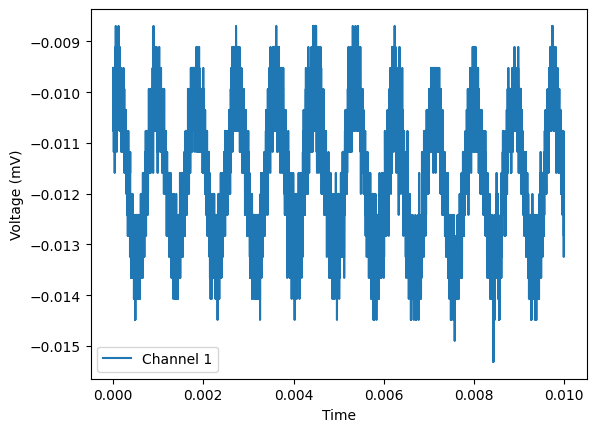

In [140]:
# Check scale and trigger level on scope
data = scope.readMemTriggered([1], timeout = 50, pts = '100k') # select channel 2 for plotting
plt.plot(data['time'], data['ch1'], label = 'Channel 1')
plt.xlabel('Time')
plt.ylabel('Voltage (mV)')
plt.legend()
plt.show()

### Forwards sweep

In [165]:
# Test position readout and tune to initialise attocube position
print(f'Position now: {amc.move.getPosition(axis)} nm = {amc.move.getPosition(axis)/1e3} um') # Position prior to moving

Position now: 5675943.684 nm = 5676.3424939999995 um


In [156]:
stepSize = 50
waitTime = 0.5 # s

forwardRange = 6000
forwardSteps = np.arange(0, forwardRange, stepSize)

Waiting for Trigger
Trigger Received


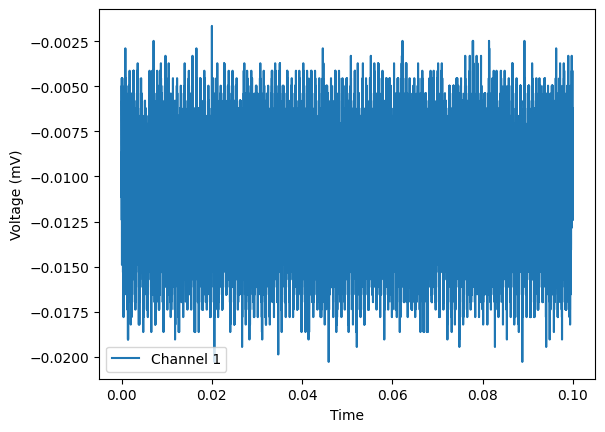

In [163]:
# Move forwards continuously and plot reflection 
amc.move.setNSteps(axis = 0, backward = False, step = forwardRange)

data = scope.readMemTriggered([1], timeout = 50, pts = '100k') # select channel 1 for plotting
plt.plot(data['time'], data['ch1'], label = 'Channel 1')
plt.xlabel('Time')
plt.ylabel('Voltage (mV)')
plt.legend()
plt.show()


### Backwards sweep

In [160]:
# Test position readout and tune to initialise attocube position
print(f'Position now: {amc.move.getPosition(axis)} nm = {amc.move.getPosition(axis)/1e3} um') # Position prior to moving

Position now: 5676829.902 nm = 5676.800621 um


In [153]:
backwardRange = 10000
backwardSteps = np.arange(0, backwardRange, stepSize)

Waiting for Trigger
Trigger Received


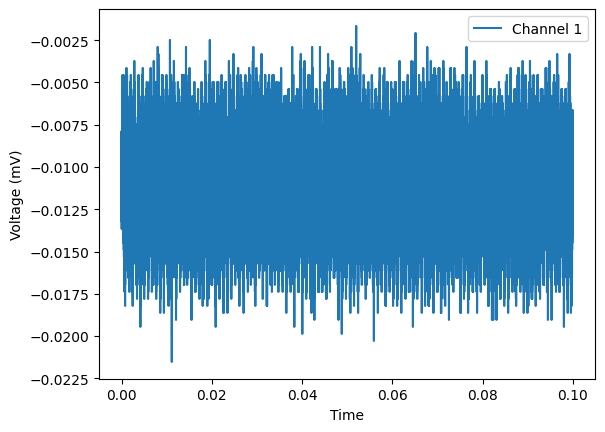

In [161]:
# Move backwards continuously and plot reflection 
amc.move.setNSteps(axis = 0, backward = True, step = backwardRange)

data = scope.readMemTriggered([1], timeout = 50, pts = '100k') # select channel 1 for plotting
plt.plot(data['time'], data['ch1'], label = 'Channel 1')
plt.xlabel('Time')
plt.ylabel('Voltage (mV)')
plt.legend()
plt.show()

### Blargh

In [4]:
# Move discretely and plot reflection with each step
# This makes more sense with detectino  on an SNSPD
for i in tqdm(range(len(forwardSteps)), desc = 'Buzzing and counting...'):
    amc.move.setNSteps(axis = 0, backward = True, step = stepSize)
    time.sleep(waitTime)


NameError: name 'forwardSteps' is not defined

Conclusion: the sample is in the mount. Whether it has lost its alugnment remains to be determined.
* nothing on the rigol with PDA05CF2
* nothing on PM100D 

It appears we are no longer aligned

# Bi-exponential fitting to Cooldown 1 data

In [5]:
# directory structure as stored on Mario
folders_1018 = (glob.glob('data/2025-10-18/confocal/*?*/*/*'))

folders_1025 = (glob.glob('data/2025-10-24/confocal/*/*') 
            +
           glob.glob('data/2025-10-25/confocal/*/*'))
folders_1025.remove('data/2025-10-24/confocal\\run3\\1514.6848')  
folders_1025.remove('data/2025-10-24/confocal\\run{runID}\\1514.6848')  

sortedFolders_1018 = sorted(folders_1018,
                       key = lambda x: os.path.basename(x))
sortedFolders_1025 = sorted(folders_1025,
                       key = lambda x: os.path.basename(x))

subFolderWavelengths_1018 = [os.path.basename(os.path.normpath(p)) for p in sortedFolders_1018]
subFolderWavelengths_1025 = [os.path.basename(os.path.normpath(p)) for p in sortedFolders_1025]

folderDates_1018 = [os.path.normpath(p).split(os.sep)[1] for p in sortedFolders_1018]
folderDates_1025 = [os.path.normpath(p).split(os.sep)[1] for p in sortedFolders_1025]

print(subFolderWavelengths_1018)
print(sortedFolders_1018)
print(subFolderWavelengths_1025)
print(sortedFolders_1025)

['1504.59024', '1506.976', '1508.22566', '1512.10873', '1514.7', '1518.08', '1521.33084']
['data/2025-10-18/confocal\\sample1\\run1\\1504.59024', 'data/2025-10-18/confocal\\sample1\\run1\\1506.976', 'data/2025-10-18/confocal\\sample1\\run1\\1508.22566', 'data/2025-10-18/confocal\\sample1\\run1\\1512.10873', 'data/2025-10-18/confocal\\sample1\\run1\\1514.7', 'data/2025-10-18/confocal\\sample1\\run1\\1518.08', 'data/2025-10-18/confocal\\sample1\\run1\\1521.33084']
['1504.59024', '1506.976', '1508.22566', '1512.10873', '1514.7', '1518.08', '1521.33084']
['data/2025-10-25/confocal\\run10\\1504.59024', 'data/2025-10-25/confocal\\run9\\1506.976', 'data/2025-10-25/confocal\\run8\\1508.22566', 'data/2025-10-25/confocal\\run7\\1512.10873', 'data/2025-10-24/confocal\\run6\\1514.7', 'data/2025-10-24/confocal\\run5\\1518.08', 'data/2025-10-24/confocal\\run4\\1521.33084']


In [6]:
# Add theoretical location of lines
lines = [199.242e6, # Cubic Z1-Y2
        198.927e6, # Cubic Z1-Y1  
        198.76215e6, # B Z1-Y1
        198.2567e6, # G1 Z1-Y2
        197.913e6, # A Z1-Y2
        197.4686e6, # G1 Z1-Y1
        197.05e6] # A Z1-Y1  ""

lines_label = [r'Cubic:$Z_1 \rightarrow Y_2$',
               r'Cubic:$Z_1 \rightarrow Y_1$',
               r'B:$Z_1 \rightarrow Y_1$',
               r'G1:$Z_1 \rightarrow Y_2$',
               r'A:$Z_1 \rightarrow Y_2$',
               r'G1:$Z_1 \rightarrow Y_1$',
               r'A:$Z_1 \rightarrow Y_1$']

cols = ['#f94144', '#f3722c', '#f8961e', '#f9c74f', '#90be6d', '#43aa8b', '#577590']

choose = [10, 40, 60, 135] 

### 18/10 Data
Less quenches at -0.82V bias, prior to attocube alignment

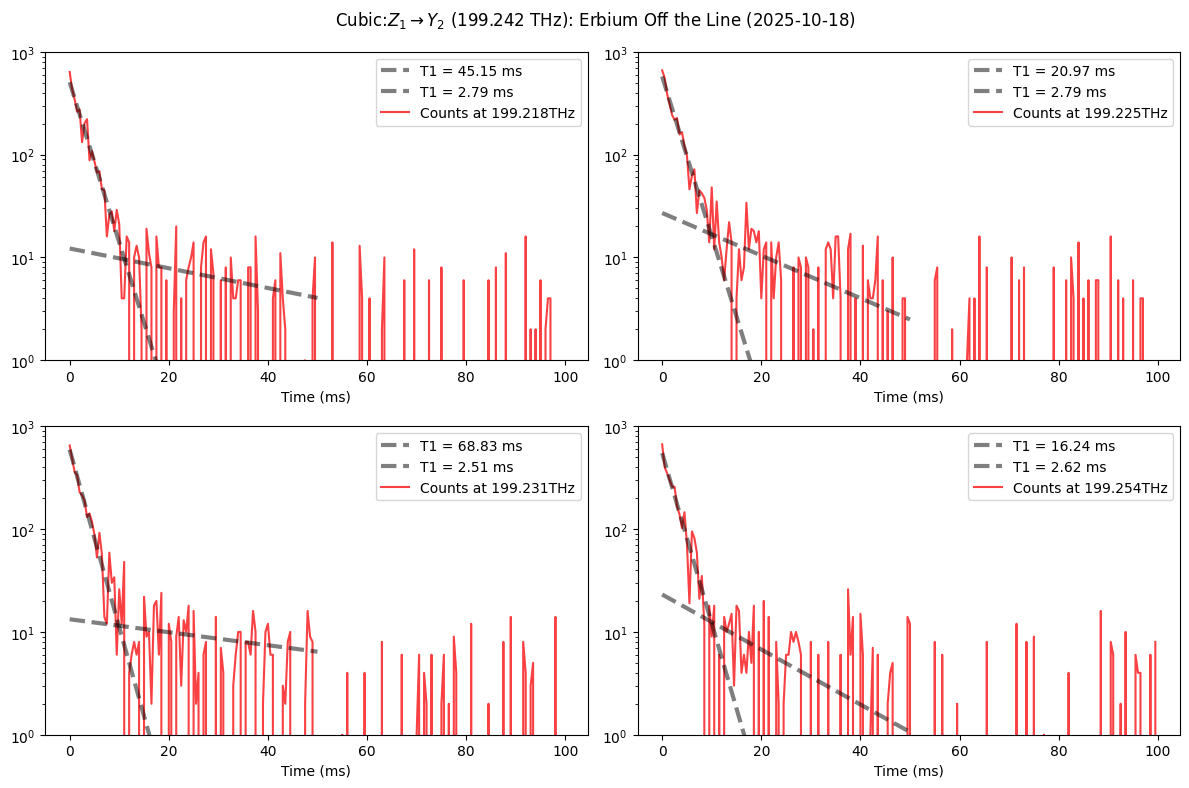

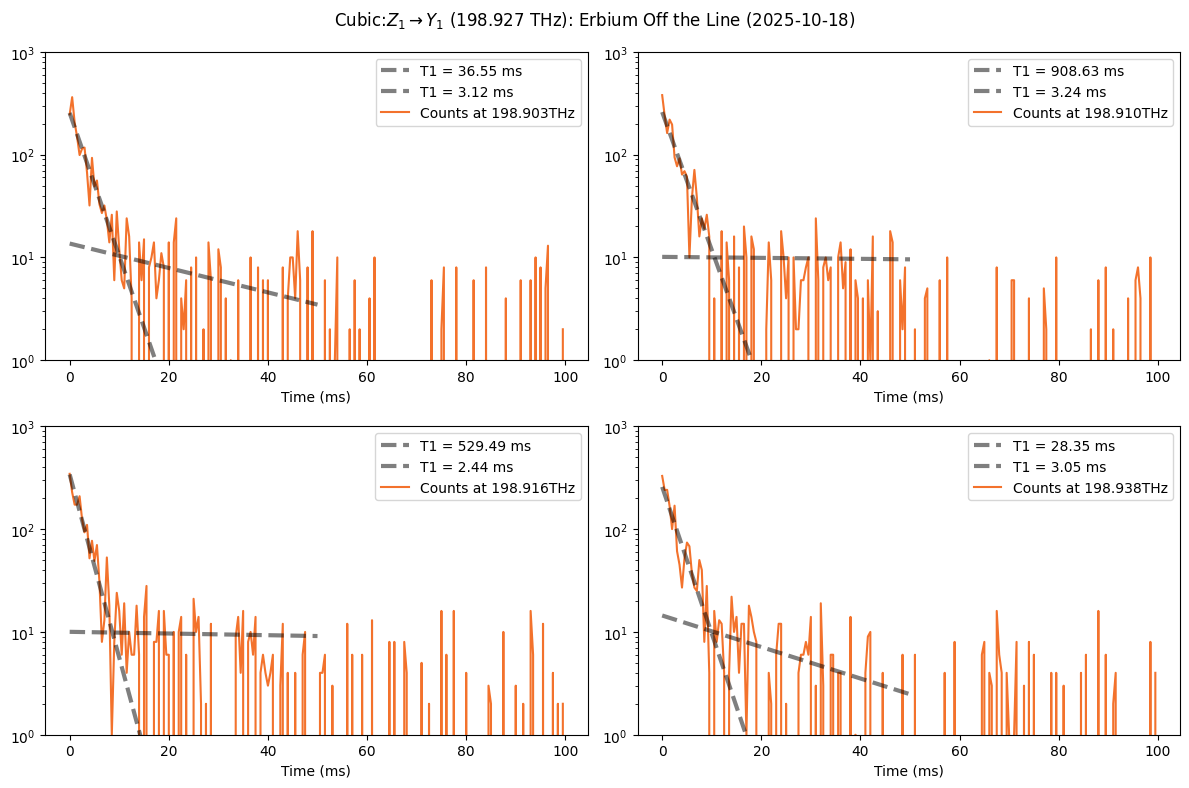

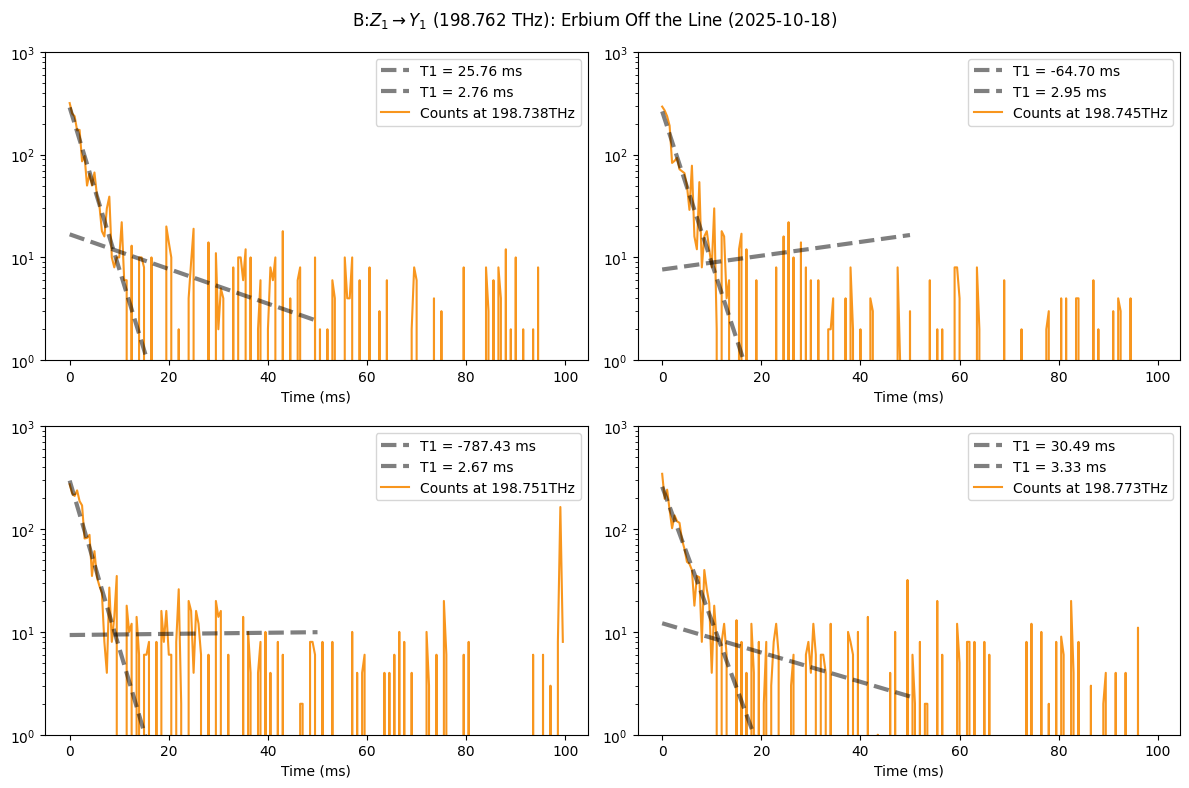

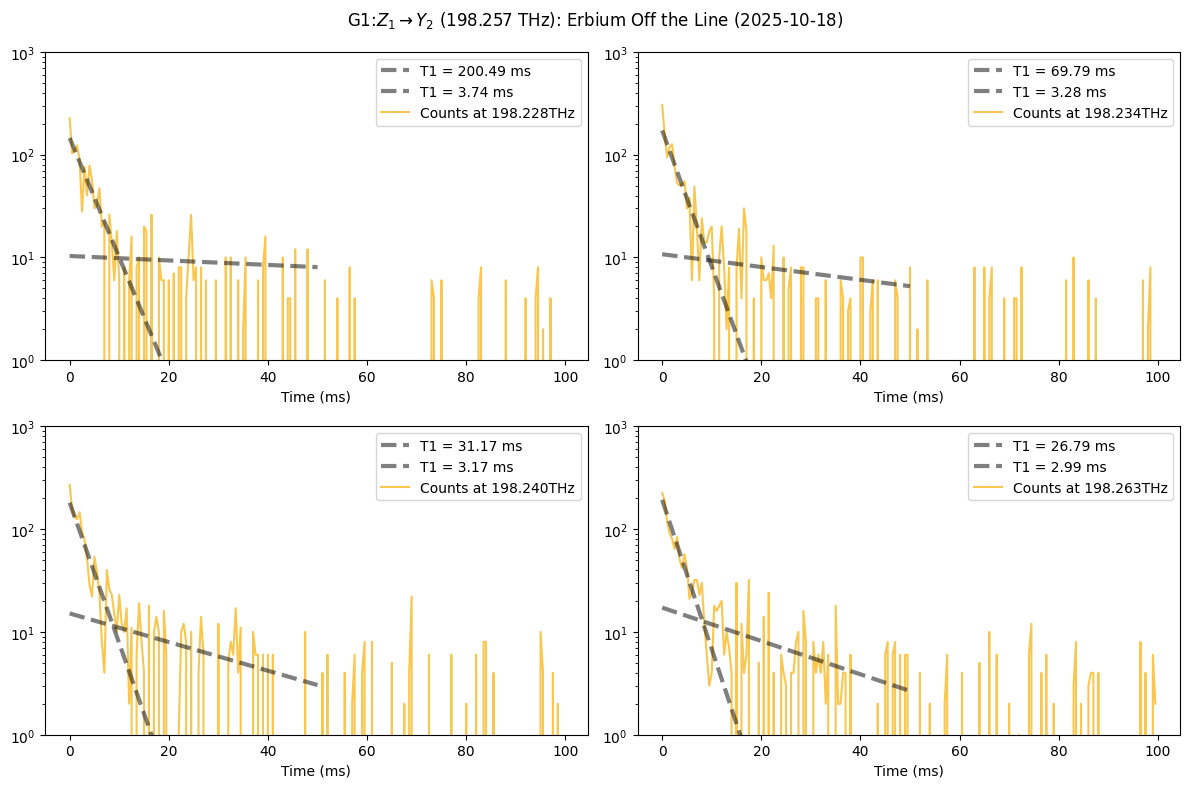

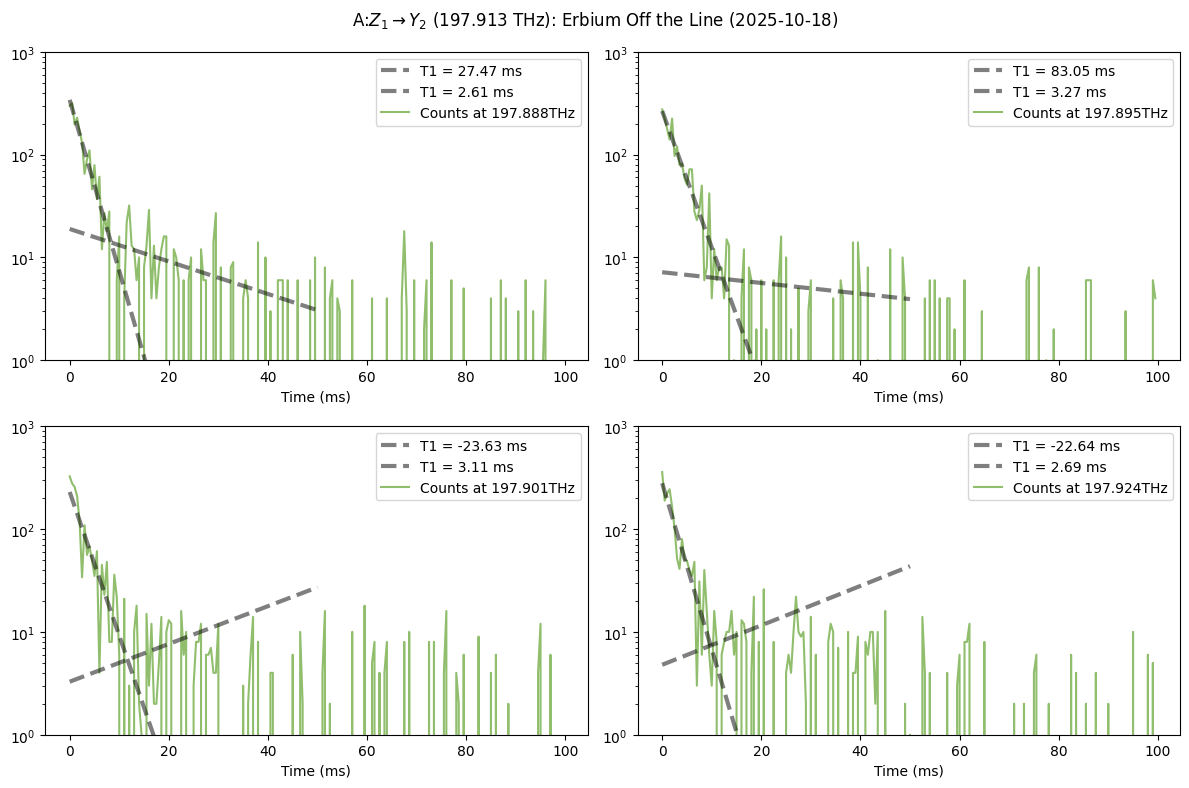

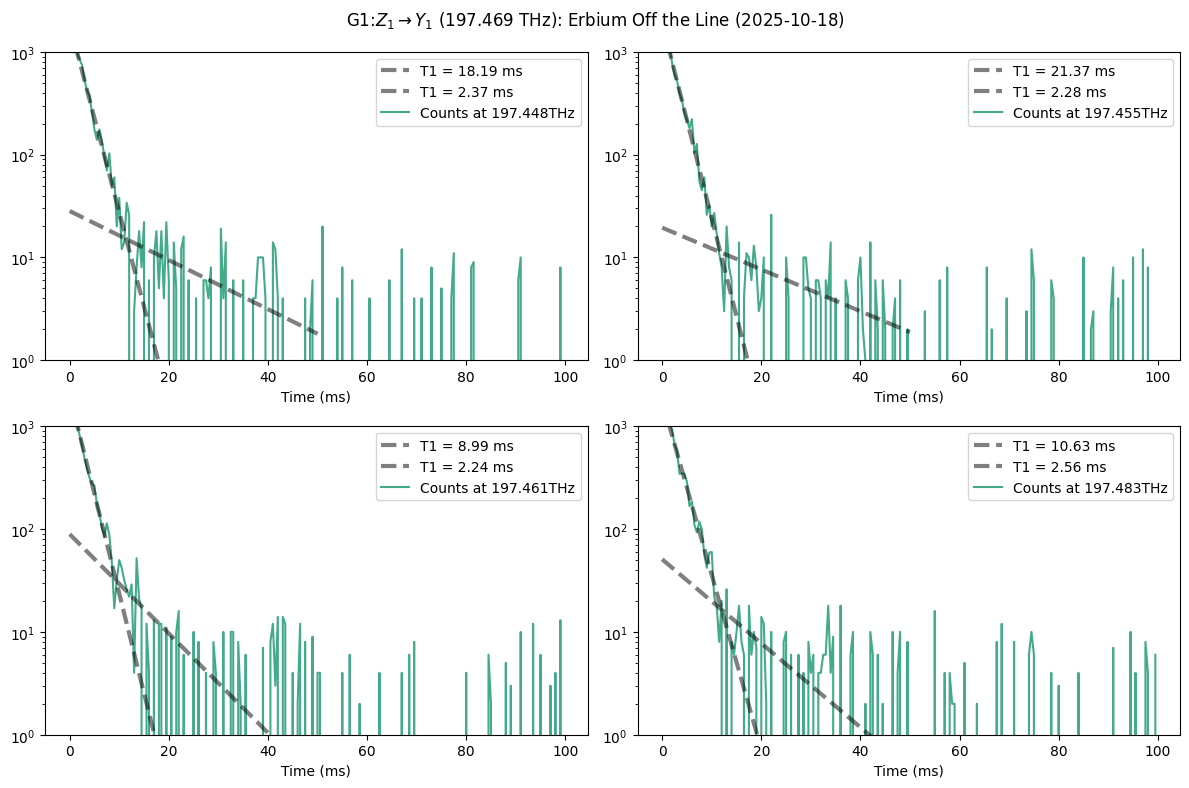

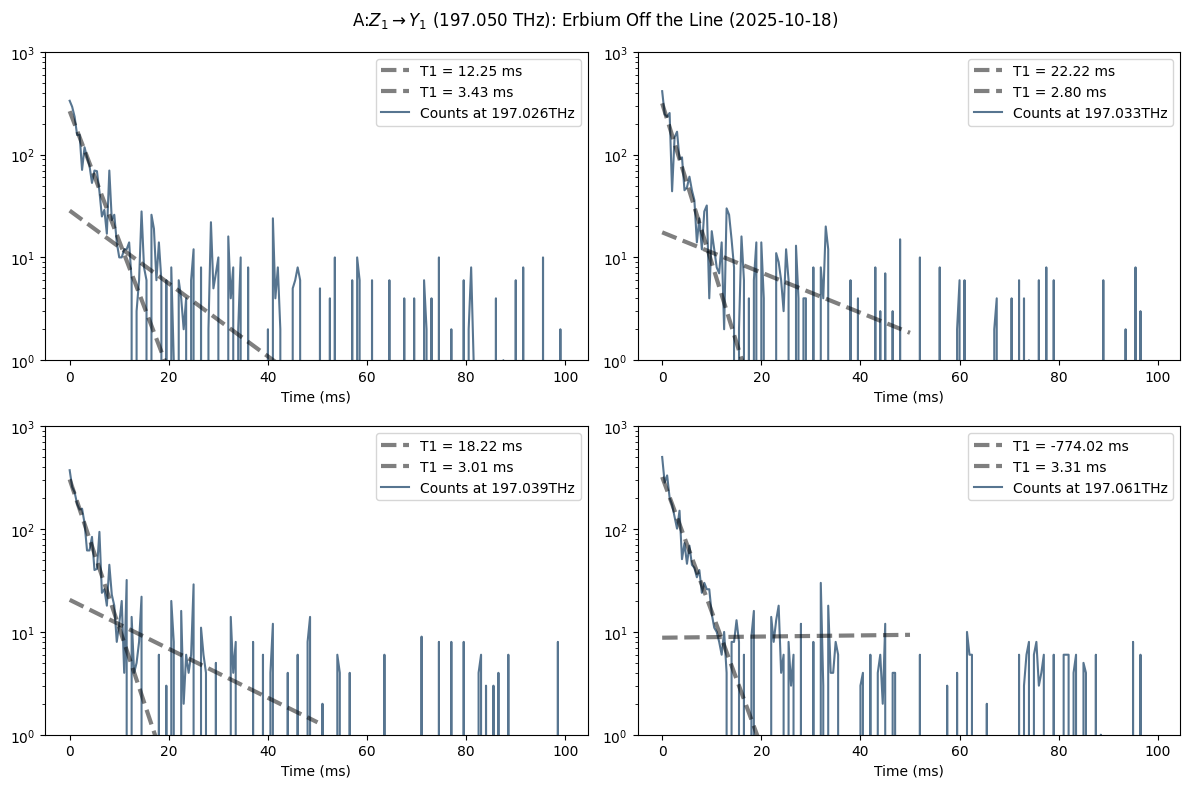

In [7]:
for i, wave in enumerate(subFolderWavelengths_1018):
    folder = sortedFolders_1018[i]
    folder_1018 = os.listdir(folder)
    fig = plt.figure(figsize = (12, 8))

    # choose to look at background time traces off the line
    choose = [15, 40, 60, 135] 

    for j, idx in enumerate(choose):
        tt = folder_1018[idx]
        ttPath = os.path.join(folder, tt)

        match = re.search(r'_freq_([0-9.]+)_MHz', tt)
        if match:
            freq = float(match.group(1))

        data = np.loadtxt(ttPath, delimiter = ',')
        subp = fig.add_subplot(2, 2, j+1)
        subp.semilogy(data[0, :]*1e3, data[1, :], c = cols[i], label = f'Counts at {freq*1e-6:.3f}THz')
        subp.set_xlabel('Time (ms)')

        # Linear regression on first 10 ms
        tFit = np.linspace(0, 50e-3, 2)

        xA = data[0, 0:20]
        yA = data[1, 0:20]
        maskA = yA > 0
        xA = xA[maskA]
        yA = yA[maskA]
        slopeA, interceptA, rA, pA, std_errA = stats.linregress(xA, np.log(yA))        
        countFitA = np.exp(slopeA * tFit + interceptA)
        subp.plot(tFit*1e3, countFitA, 
                  c = 'k', linestyle = '--', alpha = 0.5, linewidth = 3, 
                  label = rf'T1 = {-(1/slopeA) * 1e3:.2f} ms')
 
        xB = data[0, 20:50]
        yB = data[1, 20:50]
        maskB = yB > 0
        xB = xB[maskB]
        yB = yB[maskB]
        slopeB, interceptB, rB, pB, std_errB = stats.linregress(xB, np.log(yB))        
        countFitB = np.exp(slopeB * tFit + interceptB)
        subp.plot(tFit*1e3, countFitB, 
                  c = 'k', linestyle = '--', alpha = 0.5, linewidth = 3, 
                  label = rf'T1 = {-(1/slopeB) * 1e3:.2f} ms')
        
        subp.set_ylim([1, 1e3])
        handles, labels = subp.get_legend_handles_labels()
        subp.legend(handles[::-1], labels[::-1], loc='upper right')

    fig.suptitle(f'{lines_label[i]} ({lines[i]/1e6:.3f} THz): Erbium Off the Line ({folderDates_1018[i]})')
    plt.tight_layout()
    # plt.savefig(os.path.join(savePath, f'{wave} background.png'))

In [35]:
len(folder_1018) * len(subFolderWavelengths_1018)

987

In [8]:
len(subFolderWavelengths_1018)
len(folder_1018)

140

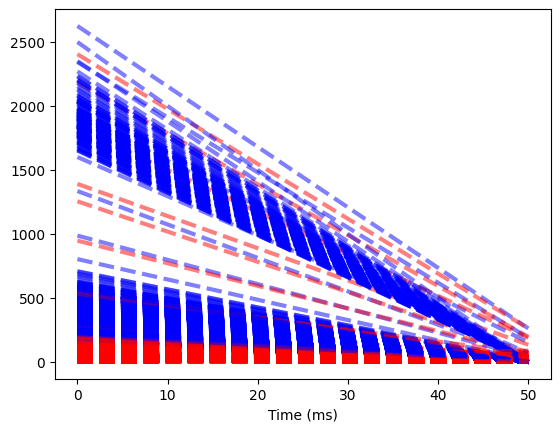

In [29]:
for i, wave in enumerate(subFolderWavelengths_1018):
    folder = sortedFolders_1018[i]
    folder_1018 = os.listdir(folder)

    lifetimes = np.zeros((3, len(folder_1018) * len(subFolderWavelengths_1018)))

    for j, idx in enumerate(np.arange(0, len(folder_1018))):
        tt = folder_1018[idx]
        if tt.lower().endswith('.csv'):
            ttPath = os.path.join(folder, tt)

            match = re.search(r'_freq_([0-9.]+)_MHz', tt)
            if match:
                freq = float(match.group(1))

            data = np.loadtxt(ttPath, delimiter = ',')
            # plt.semilogy(data[0, :]*1e3, data[1, :], c = cols[i], label = f'Counts at {freq*1e-6:.3f} THz')
            plt.xlabel('Time (ms)')
            tFit = np.linspace(0, 50e-3, 2)

            # Shorter lifetimes, masking out zero counts
            xA = data[0, 0:20]
            yA = data[1, 0:20]
            maskA = yA > 0
            xA = xA[maskA]
            yA = yA[maskA]

            slopeA, interceptA, rA, pA, std_errA = stats.linregress(xA, np.log(yA))        
            countFitA = np.exp(slopeA * tFit + interceptA)
            plt.plot(tFit*1e3, countFitA, 
                    c = 'b', linestyle = '--', alpha = 0.5, linewidth = 3, 
                    label = rf'T1 = {-(1/slopeA) * 1e3:.2f} ms')
    
            # Longer lifetimes, masking out zero counts
            xB = data[0, 20:50]
            yB = data[1, 20:50]
            maskB = yB > 0
            xB = xB[maskB]
            yB = yB[maskB]

            slopeB, interceptB, rB, pB, std_errB = stats.linregress(xB, np.log(yB))        
            countFitB = np.exp(slopeB * tFit + interceptB)
            plt.plot(tFit*1e3, countFitB, 
                    c = 'r', linestyle = '--', alpha = 0.5, linewidth = 3, 
                    label = rf'T1 = {-(1/slopeB) * 1e3:.2f} ms')
            
        # Save lifetimes
        lifetimes[0, i*len(folder_1018) + j - 1] = freq
        lifetimes[1, i*len(folder_1018) + j - 1] = -1/slopeA # short lifetime
        lifetimes[2, i*len(folder_1018) + j - 1] =  -1/slopeB # long lifetime


In [28]:
1*len(folder_1018) + 140 - 1

279

In [35]:
# I don't think this is updating correctly - check later
lifetimes_df = pd.DataFrame(lifetimes.T)
display(lifetimes_df)

,0,1,2
0,0.0,0.000000,0.000000
1,0.0,0.000000,0.000000
2,0.0,0.000000,0.000000
3,0.0,0.000000,0.000000
4,0.0,0.000000,0.000000
...,...,...,...
975,197060966.0,0.002707,0.039427
976,197061238.0,0.003316,-0.116563
977,197061523.0,0.002949,0.019066
978,197061777.0,0.002581,0.013519


# Understanding Lifetimes
* Lifetimes with frequency, split into T_short and T_long
* Lifetime histograms, split into T_short and T_long

### 25/10 Data
More quenches at -0.9V, but aligned off fluorescence on attocube

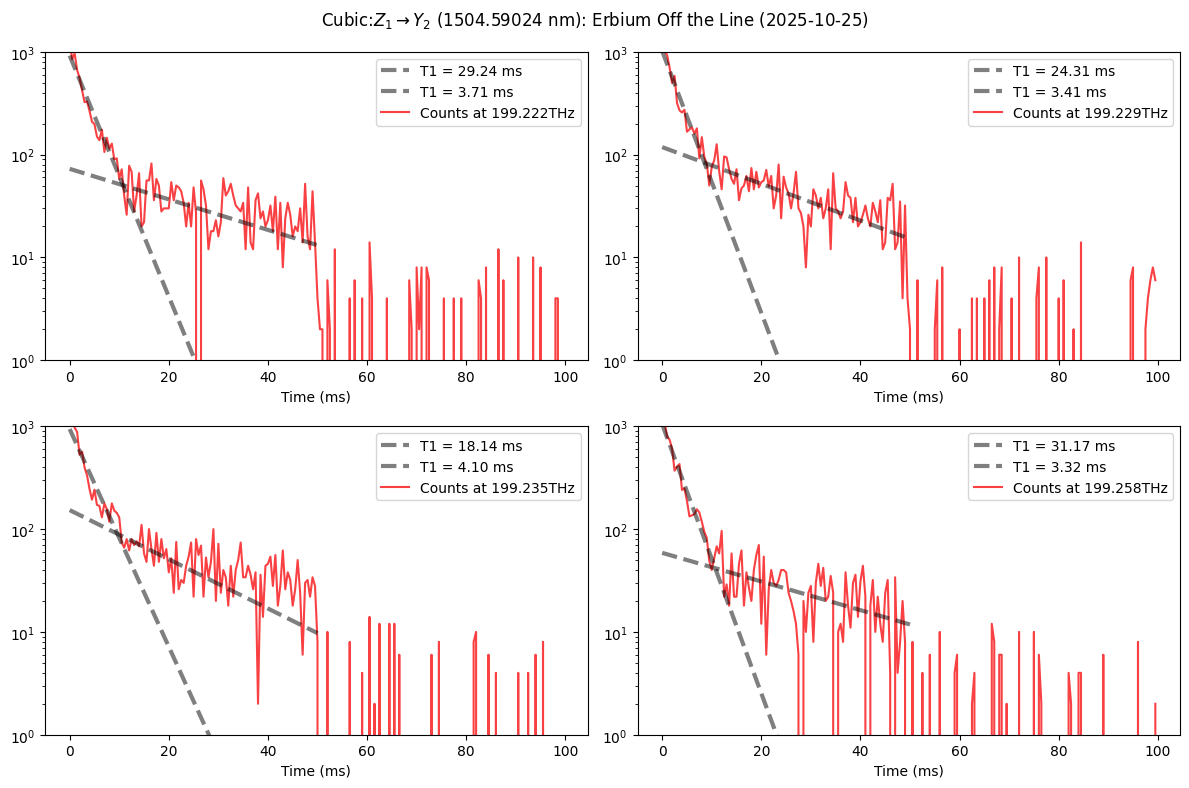

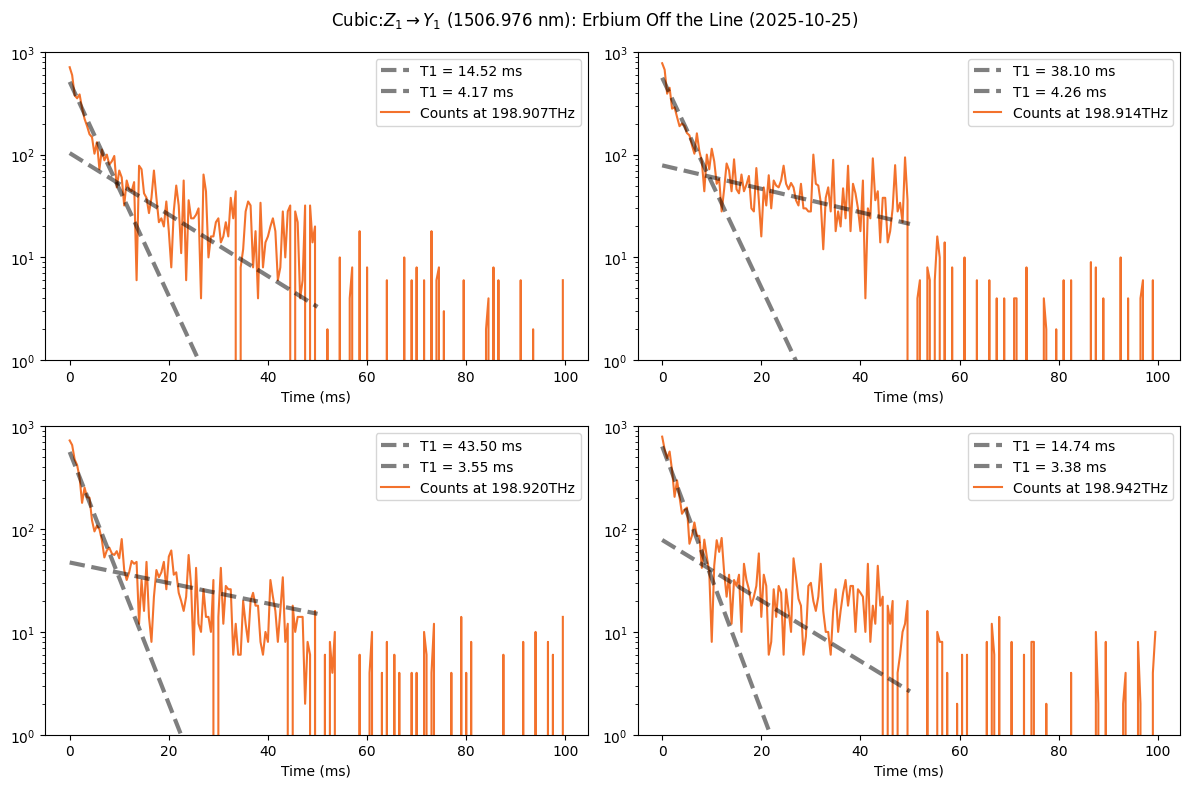

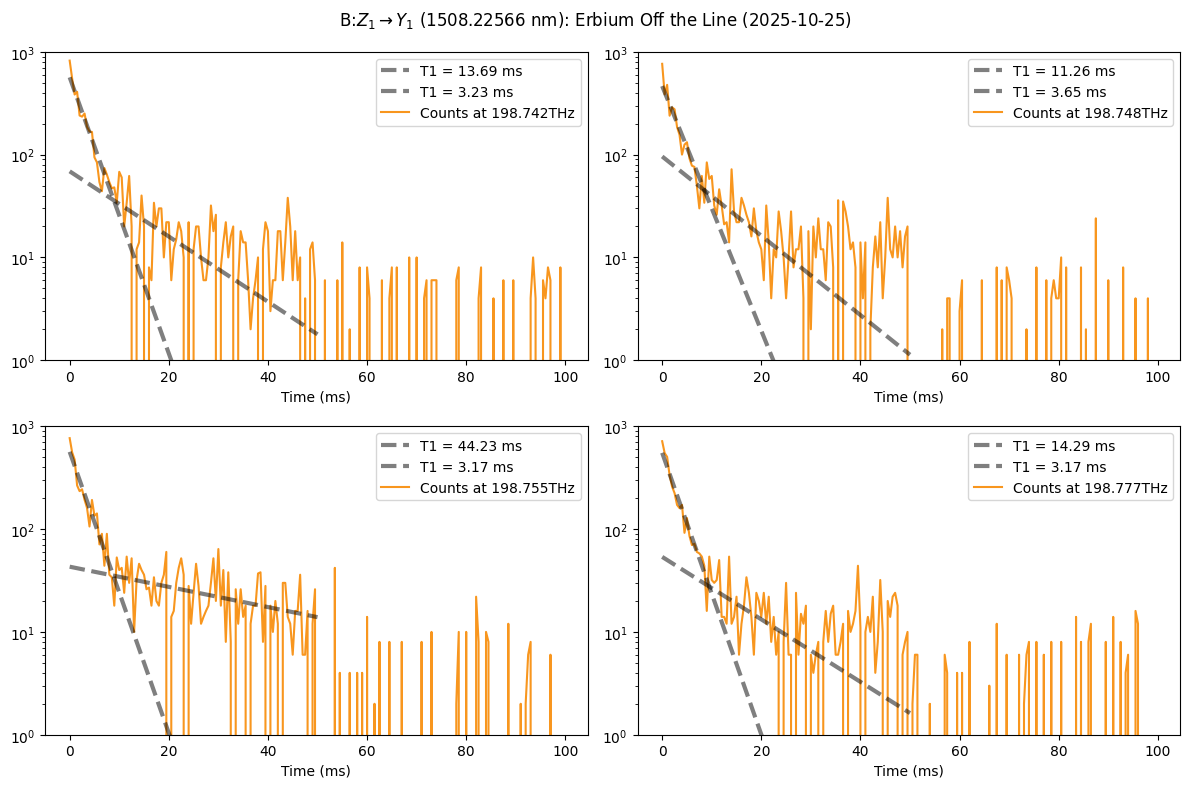

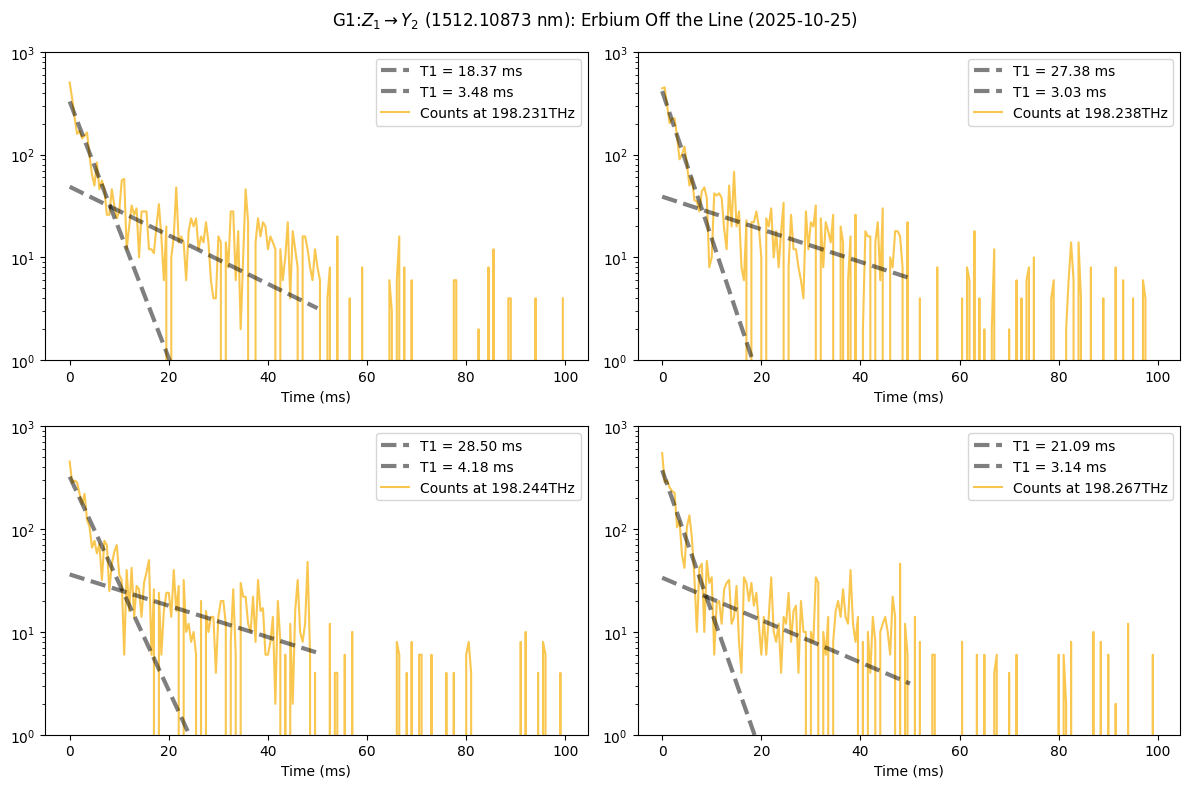

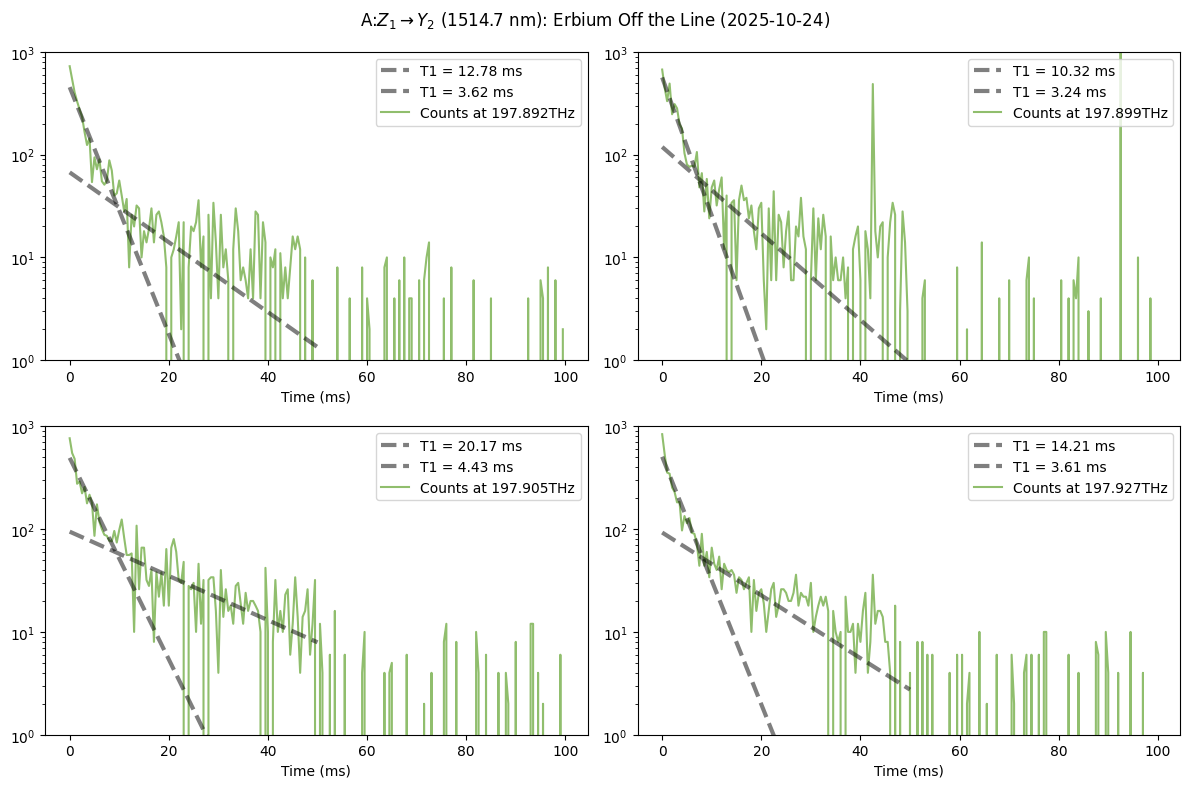

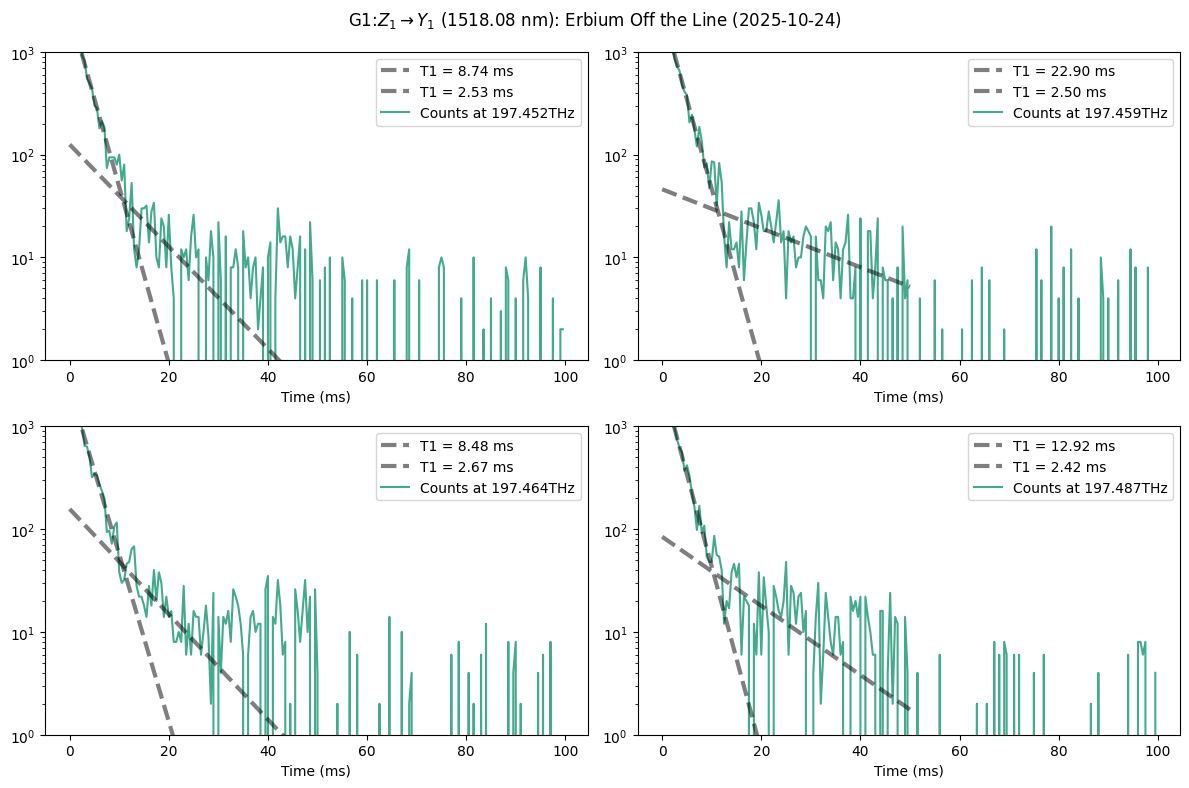

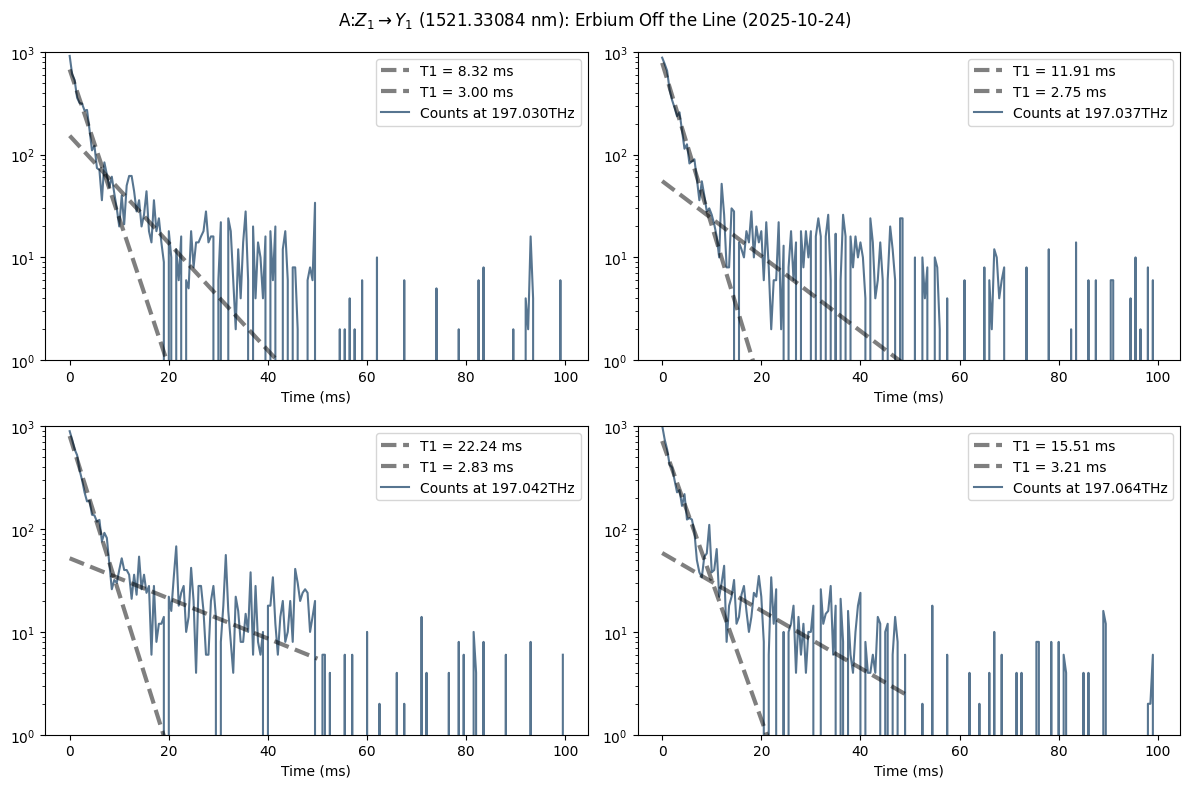

In [ ]:
for i, wave in enumerate(subFolderWavelengths_1025):
    folder = sortedFolders_1025[i]
    folder_1025 = os.listdir(folder)
    fig = plt.figure(figsize = (12, 8))

    # choose to look at background time traces off the line
    choose = [15, 40, 60, 135] 

    for j, idx in enumerate(choose):
        tt = folder_1025[idx]
        ttPath = os.path.join(folder, tt)

        match = re.search(r'_freq_([0-9.]+)_MHz', tt)
        if match:
            freq = float(match.group(1))

        data = np.loadtxt(ttPath, delimiter = ',')
        subp = fig.add_subplot(2, 2, j+1)
        subp.semilogy(data[0, :]*1e3, data[1, :], c = cols[i], label = f'Counts at {freq*1e-6:.3f}THz')
        subp.set_xlabel('Time (ms)')

        # Linear regression with bi-exponential fit
        tFit = np.linspace(0, 50e-3, 2)

        # Mask non-zero values
        xA = data[0, 0:20]
        yA = data[1, 0:20]
        maskA = yA > 0
        xA = xA[maskA]
        yA = yA[maskA]
        slopeA, interceptA, rA, pA, std_errA = stats.linregress(xA, np.log(yA))
        countFitA = np.exp(slopeA * tFit + interceptA)
        subp.plot(tFit*1e3, countFitA, 
                  c = 'k', linestyle = '--', alpha = 0.5, linewidth = 3, 
                  label = rf'T1 = {-(1/slopeA) * 1e3:.2f} ms')
        
        # Mask non-zero values
        xB = data[0, 20:50]
        yB = data[1, 20:50]
        maskB = yB > 0
        xB = xB[maskB]
        yB = yB[maskB]
        slopeB, interceptB, rB, pB, std_errB = stats.linregress(xB, np.log(yB))
        countFitB = np.exp(slopeB * tFit + interceptB)
        subp.plot(tFit*1e3, countFitB, 
                  c = 'k', linestyle = '--', alpha = 0.5, linewidth = 3, 
                  label = rf'T1 = {-(1/slopeB) * 1e3:.2f} ms')
        
        subp.set_ylim([1, 1e3])
        handles, labels = subp.get_legend_handles_labels()
        subp.legend(handles[::-1], labels[::-1], loc='upper right')

    fig.suptitle(f'{lines_label[i]} ({wave} nm): Erbium Off the Line ({folderDates_1025[i]})')
    plt.tight_layout()
    # plt.savefig(os.path.join(savePath, f'{wave} background.png'))

# We are so back
### 2026-1-9 SNPSD Testing

### -0.82 Bias

In [185]:
bias = -0.82
exhp.reset_detector(detectorOut, bias, sleepTime = 0.5)
print(exhp.get_detector_current(dmm)*1e6, 'uA')

5.116182 uA


In [10]:
print(exhp.get_detector_current(dmm)*1e6, 'uA')

5.100268 uA


### 0V Bias

In [8]:
bias = 0
exhp.reset_detector(detectorOut, bias, sleepTime = 0.5)
print(exhp.get_detector_current(dmm)*1e6, 'uA')

0.030574630000000002 uA


In [73]:
print(exhp.get_detector_current(dmm)*1e6, 'uA')

0.02636415 uA


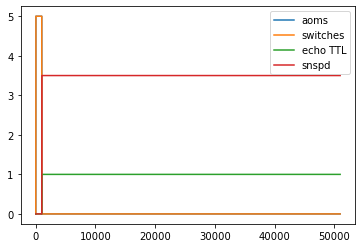

In [7]:
# Excite for 1ms; count for 50ms
exhp.set_up_echo_SNSPD(awg, 0, 1e3, 1, countFor = 50e3, switchPreDelay = 0, plotting = True)
exhp.set_deadcycles(awg, 2, channels = [1, 2, 3, 4])

In [98]:
exhp.set_up_echo_SNSPD(awg, 0, 1e3, 1, countFor = 50e3, switchPreDelay = 0, plotting = False)

In [99]:
exhp.all_on(awg)

In [41]:
TimeTagger.freeTimeTagger(tt)

True

# 14/01
Sneaking suspicion that large spikes in noise are correlated with still heater - can be detected on mains (off PSU rack) and off UPS battery. Otherwise another source in the fridge.
* Bursts all the way until ~16:30, with turning on still heater

In [ ]:
### Swabian timetagger
import TimeTagger
tt = TimeTagger.createTimeTagger()

# Setting up time-tagger histogram channel
# Parameters taken from 20251015 flashy country.ipynb 
ps = 1e12 # [ps/s] - picoseconds per second. As usual I try to frame variables in SI units, but Swabian is in picoseconds. :((
binwidth = 500e-9 * ps  # 0.1 ms, in picoseconds - [s] * [ps/s]
n_bins = 80 # number of bins

hist = TimeTagger.Histogram(tagger = tt, start_channel = 2, click_channel = 1, binwidth = binwidth, n_bins = n_bins)
tt.setTriggerLevel(2, 0.25)      # starts channel trigger level = 250 mV (signal is 500 mV)
tt.setTriggerLevel(1, 0.03)      # click channel trigger level = 30 mV
tt.setDeadtime(1, 30e-9 * ps)

ttStream = TimeTagger.TimeTagStream(tagger = tt, n_max_events = 1e9, channels = [1]) # channel 1 measures clicks from SNSPDs

In [10]:
hist = TimeTagger.Histogram(tagger = tt, start_channel = 2, click_channel = 1, binwidth = binwidth, n_bins = n_bins)

tt.setTriggerLevel(1, 0.03)      # click channel trigger level = 30 mV
tt.setDeadtime(1, 50e-9 * ps) #50 ns dead time 

tt.setTriggerLevel(2, 0.25)      # starts channel trigger level = 250 mV (signal is 500 mV)
tt.setDeadtime(2, 5e-9 * ps) # 5 ns dead time

ttStream = TimeTagger.TimeTagStream(tagger = tt, n_max_events = 2e9, channels = [1]) # channel 1 measures clicks from SNSPDs

In [ ]:
def captureTags(ttStream, bias):

    ttLive = ttStream.getData()
    localTime = time.localtime()
    ttTimes = ttLive.getTimestamps()
    ttChannels = ttLive.getChannels()

    plt.figure(figsize = (12, 6))
    # plt.hist((ttTimes - np.max(ttTimes))/1e12, bins = 500)
    plt.hist(ttTimes/1e12, bins = 500)
    plt.xlabel('Time (s)') # I am not convinced...
    plt.ylabel('Number of Clicks')
    plt.title(fr'{bias} V bias, all on mains supply [{time.asctime(localTime)}]')
    plt.show()

    binnedTags = np.histogram(ttTimes, bins = 500)
    binnedCounts = binnedTags[0]
    binnedTimes = binnedTags[1]

    print(fr'Missed counts since last data retrieval: {ttStream.getCounts()}')
    print(fr'Average counts per bin: {np.average(binnedCounts)}')

    return

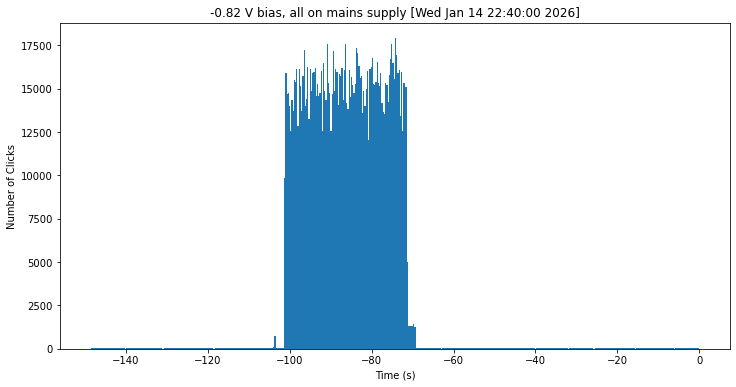

Missed counts since last data retrieval: 86
Average counts per bin: 3116.016


In [97]:
# Ben's overnight experiment
captureTags(ttStream, bias)

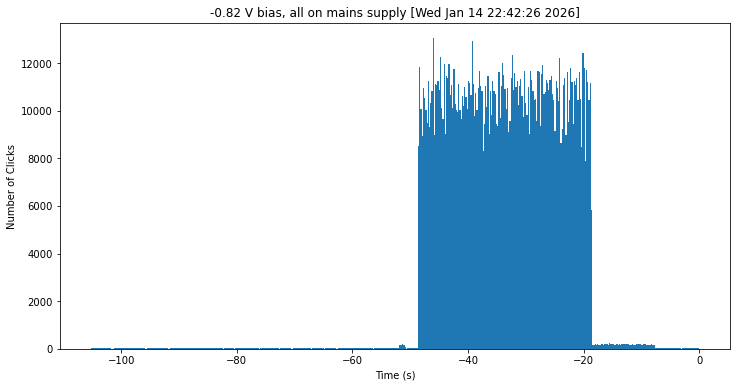

Missed counts since last data retrieval: 98
Average counts per bin: 3070.612


In [100]:
# Ben's overnight experiment
captureTags(ttStream, bias)

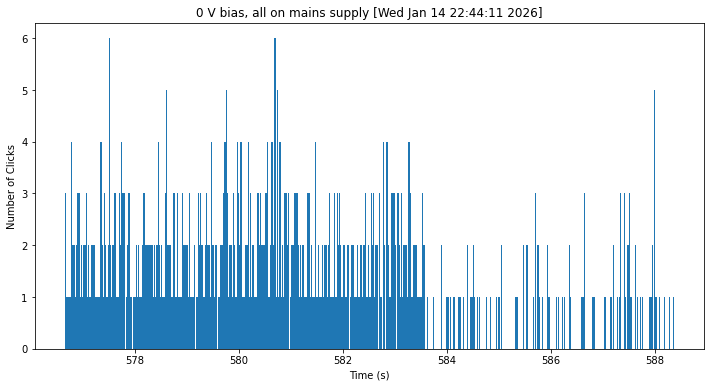

Missed counts since last data retrieval: 21
Average counts per bin: 1.328


In [109]:
# switch fro -0.82 to 0 V bias voltage
captureTags(ttStream, bias)

In [112]:
print(exhp.get_detector_current(dmm)*1e6, 'uA')

0.0343783 uA


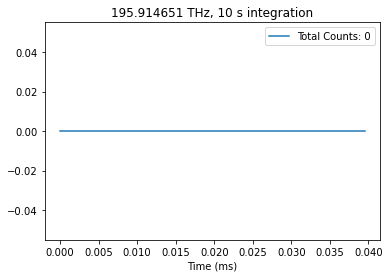

In [11]:
intTime = 2
times, timeTags = exhp.getHistDataWrapped(hist, intTime = intTime)
exhp.getHistogram(hist, wm, 10, 'lin')

### Testing live counts

### -0.82 V bias

In [131]:
bias = -0.82
exhp.reset_detector(detectorOut, bias, sleepTime = 0.5)
print(fr'SNSPD bias current: {exhp.get_detector_current(dmm)*1e6} uA')

SNSPD bias current: 5.09096 uA


In [120]:
print(exhp.get_detector_current(dmm)*1e6, 'uA')

5.082777 uA


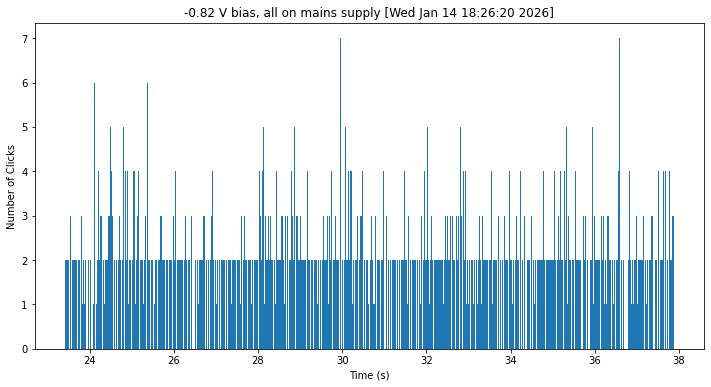

Missed counts since last data retrieval: 186
Average counts over measurement interval: 3.61


In [192]:
ttLive = ttStream.getData()
localTime = time.localtime()
ttTimes = ttLive.getTimestamps()
ttChannels = ttLive.getChannels()

plt.figure(figsize = (12, 6))
plt.hist(ttTimes/1e12, bins = 1000)

plt.xlabel('Time (s)') # I am not convinced...
plt.ylabel('Number of Clicks')
plt.title(fr'{bias} V bias, all on mains supply [{time.asctime(localTime)}]')
plt.show()

binnedTags = np.histogram(ttTimes, bins = 500)
binnedCounts = binnedTags[0]
binnedTimes = binnedTags[1]

print(fr'Missed counts since last data retrieval: {ttStream.getCounts()}')
print(fr'Average counts over measurement interval: {np.average(binnedCounts)}')

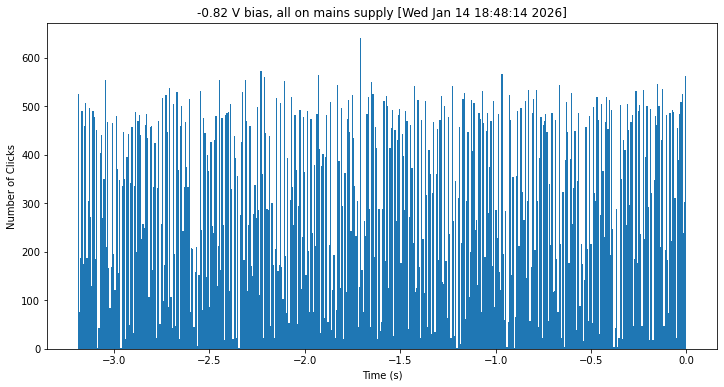

Missed counts since last data retrieval: 18226
Average counts per bin: 304.022


In [217]:
# new deadtime config on time tagger
ttLive = ttStream.getData()
localTime = time.localtime()
ttTimes = ttLive.getTimestamps()
ttChannels = ttLive.getChannels()

plt.figure(figsize = (12, 6))
plt.hist((ttTimes - np.max(ttTimes))/1e12, bins = 500)


plt.xlabel('Time (s)') # I am not convinced...
plt.ylabel('Number of Clicks')
plt.title(fr'{bias} V bias, all on mains supply [{time.asctime(localTime)}]')
plt.show()

binnedTags = np.histogram(ttTimes, bins = 500)
binnedCounts = binnedTags[0]
binnedTimes = binnedTags[1]

print(fr'Missed counts since last data retrieval: {ttStream.getCounts()}')
print(fr'Average counts per bin: {np.average(binnedCounts)}')

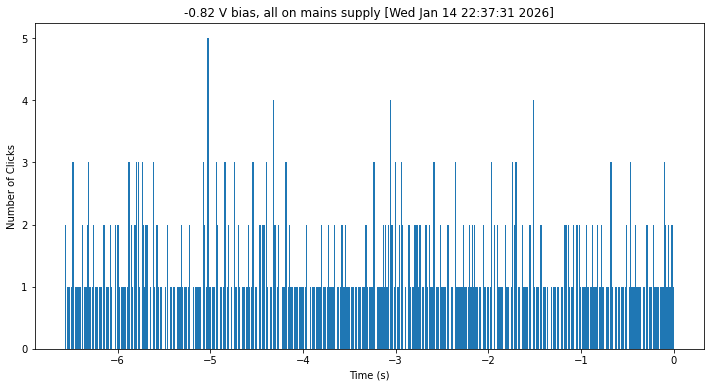

Missed counts since last data retrieval: 77
Average counts per bin: 1.02


In [92]:
# new deadtime config on time tagger
ttLive = ttStream.getData()
localTime = time.localtime()
ttTimes = ttLive.getTimestamps()
ttChannels = ttLive.getChannels()

plt.figure(figsize = (12, 6))
plt.hist((ttTimes - np.max(ttTimes))/1e12, bins = 500)


plt.xlabel('Time (s)') # I am not convinced...
plt.ylabel('Number of Clicks')
plt.title(fr'{bias} V bias, all on mains supply [{time.asctime(localTime)}]')
plt.show()

binnedTags = np.histogram(ttTimes, bins = 500)
binnedCounts = binnedTags[0]
binnedTimes = binnedTags[1]

print(fr'Missed counts since last data retrieval: {ttStream.getCounts()}')
print(fr'Average counts per bin: {np.average(binnedCounts)}')

### 0 V Bias

In [126]:
bias = 0
exhp.reset_detector(detectorOut, bias, sleepTime = 0.5)
print(fr'SNSPD bias current: {exhp.get_detector_current(dmm)*1e6} uA')

SNSPD bias current: -0.001571834 uA


In [127]:
print(exhp.get_detector_current(dmm)*1e6, 'uA')

0.003783021 uA


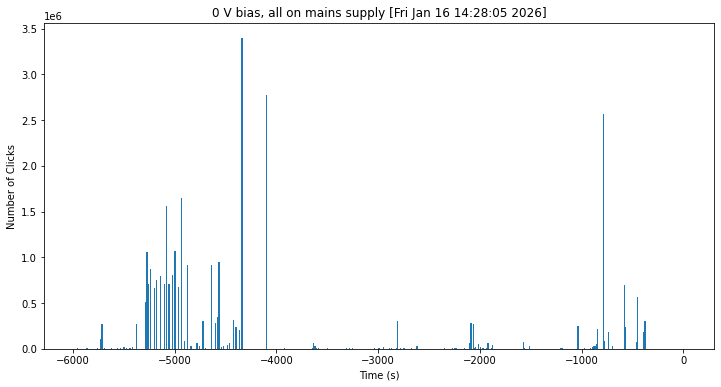

Missed counts since last data retrieval: 0
Average counts over measurement interval: 63497.438


In [128]:
ttLive = ttStream.getData()
localTime = time.localtime()
timeTime = time.time()
ttTimes = ttLive.getTimestamps()
ttChannels = ttLive.getChannels()

plt.figure(figsize = (12, 6))
plt.hist((ttTimes - np.max(ttTimes))/1e12, bins = 500)
plt.xlabel('Time (s)') # I am not convinced... check units
plt.ylabel('Number of Clicks')
plt.title(fr'{bias} V bias, all on mains supply [{time.asctime(localTime)}]')
plt.show()

binnedTags = np.histogram(ttTimes, bins = 500)
binnedCounts = binnedTags[0]
binnedTimes = binnedTags[1]

print(fr'Missed counts since last data retrieval: {ttStream.getCounts()}')
print(fr'Average counts over measurement interval: {np.average(binnedCounts)}')

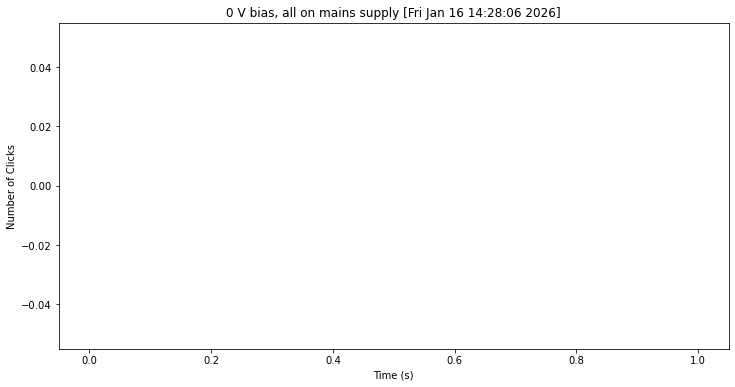

Missed counts since last data retrieval: 0
Average counts per bin: 0.0


In [129]:
ttLive = ttStream.getData()
localTime = time.localtime()
ttTimes = ttLive.getTimestamps()
ttChannels = ttLive.getChannels()

plt.figure(figsize = (12, 6))
plt.hist(ttTimes/1e12, bins = 500)

plt.xlabel('Time (s)') # I am not convinced...
plt.ylabel('Number of Clicks')
plt.title(fr'{bias} V bias, all on mains supply [{time.asctime(localTime)}]')
plt.show()

binnedTags = np.histogram(ttTimes, bins = 500)
binnedCounts = binnedTags[0]
binnedTimes = binnedTags[1]

print(fr'Missed counts since last data retrieval: {ttStream.getCounts()}')
print(fr'Average counts per bin: {np.average(binnedCounts)}')

In [130]:
# new deadtime config on time tagger
ttLive = ttStream.getData()
localTime = time.localtime()
ttTimes = ttLive.getTimestamps()
ttChannels = ttLive.getChannels()

plt.figure(figsize = (12, 6))
plt.hist((ttTimes - np.max(ttTimes))/1e12, bins = 500)


plt.xlabel('Time (s)') # I am not convinced...
plt.ylabel('Number of Clicks')
plt.title(fr'{bias} V bias, all on mains supply [{time.asctime(localTime)}]')
plt.show()

binnedTags = np.histogram(ttTimes, bins = 500)
binnedCounts = binnedTags[0]
binnedTimes = binnedTags[1]

print(fr'Missed counts since last data retrieval: {ttStream.getCounts()}')
print(fr'Average counts per bin: {np.average(binnedCounts)}')

ValueError: zero-size array to reduction operation maximum which has no identity

<Figure size 864x432 with 0 Axes>

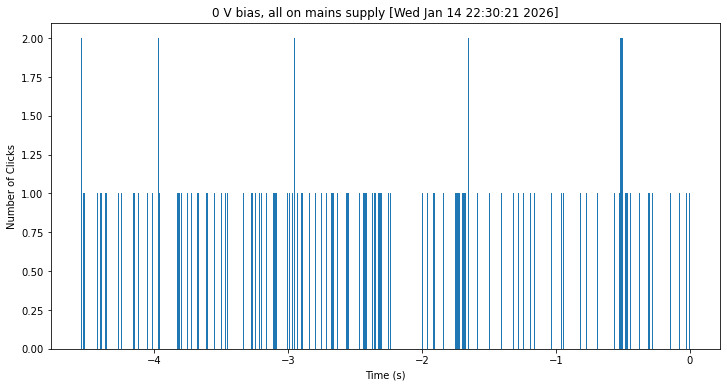

Missed counts since last data retrieval: 7
Average counts per bin: 0.216


In [ ]:
# new deadtime config on time tagger
ttLive = ttStream.getData()
localTime = time.localtime()
ttTimes = ttLive.getTimestamps()
ttChannels = ttLive.getChannels()

plt.figure(figsize = (12, 6))
plt.hist((ttTimes - np.max(ttTimes))/1e12, bins = 500)


plt.xlabel('Time (s)') # I am not convinced...
plt.ylabel('Number of Clicks')
plt.title(fr'{bias} V bias, all on mains supply [{time.asctime(localTime)}]')
plt.show()

binnedTags = np.histogram(ttTimes, bins = 500)
binnedCounts = binnedTags[0]
binnedTimes = binnedTags[1]

print(fr'Missed counts since last data retrieval: {ttStream.getCounts()}')
print(fr'Average counts per bin: {np.average(binnedCounts)}')

### Time testing

In [ ]:
print(timeTime)
print((np.max(ttTimes)-np.min(ttTimes))/1e12) # 108s measurement

1768374091.1719809
108.198536139385


# 15/01
Let's ignore the noise and see what happens
### Time Tagger Setup

In [69]:
ps = 1e12 # [ps/s] - picoseconds per second. As usual I try to frame variables in SI units, but Swabian is in picoseconds. :((
binWidth = 5e-5 * ps  
nBins = 1e4 # number of bins

In [70]:
### Swabian timetagger
import TimeTagger
tt = TimeTagger.createTimeTagger()

# Channel setup
tt.setTriggerLevel(1, 0.03) # click channel trigger level = 30 mV
tt.setDeadtime(1, 50e-9 * ps) # 50 ns dead time 
tt.setTriggerLevel(2, 0.25) # starts channel trigger level = 250 mV (signal is 500 mV)
tt.setDeadtime(2, 5e-9 * ps) # 5 ns dead time

ttStream = TimeTagger.TimeTagStream(tagger = tt, 
                                    n_max_events = 1e9, 
                                    channels = [1]) 
hist = TimeTagger.Histogram(tagger = tt, 
                            start_channel = 2, 
                            click_channel = 1, 
                            binwidth = binWidth, 
                            n_bins = nBins)


In [ ]:
def captureTags(ttStream, bias, duration, bins):

    ttLive = ttStream.getData()
    localTime = time.localtime()
    ttTimes = ttLive.getTimestamps()
        
    ttChannels = ttLive.getChannels()

    plt.figure(figsize = (12, 6))
    plt.hist((ttTimes - np.max(ttTimes))/1e12, bins = bins)
    # plt.hist(ttTimes * ps, bins = 500)
    plt.xlabel('Time (s)') # I am not convinced...
    plt.ylabel('Number of Clicks')
    plt.title(fr'{bias} V bias, all on mains supply [{time.asctime(localTime)}]')
    plt.show()

    binnedTags = np.histogram(ttTimes / ps, bins = 500) # absoliute times here
    binnedCounts = binnedTags[0]
    binnedTimes = binnedTags[1]

    print(fr'Missed counts since last data retrieval: {ttStream.getCounts()}')
    print(fr'Average counts per bin: {np.average(binnedCounts)}')

    return

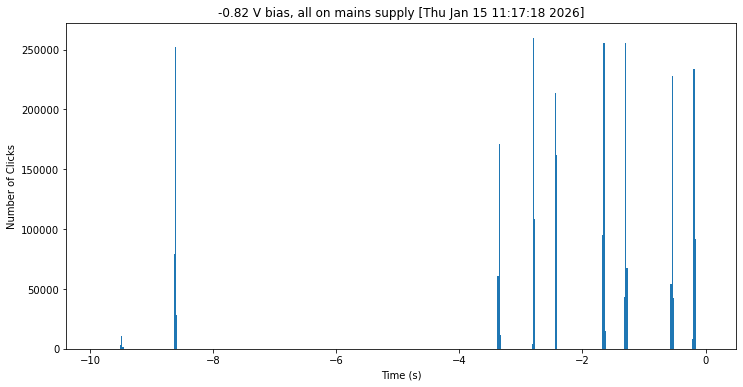

Average counts per bin: 5516.622


In [58]:
captureTags(ttStream, bias)

SNSPD bias current: 5.1177470000000005 uA


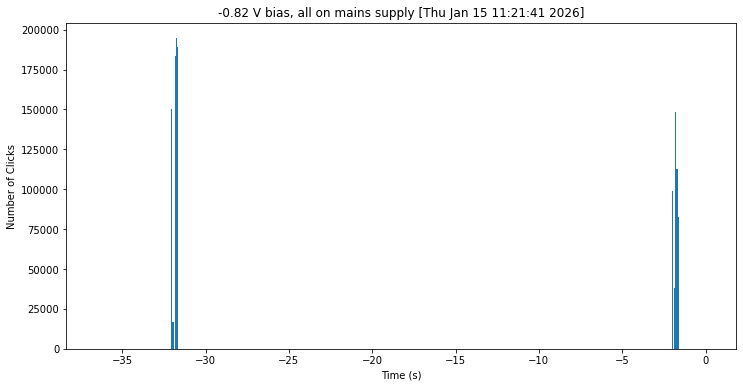

Average counts per bin: 2437.224


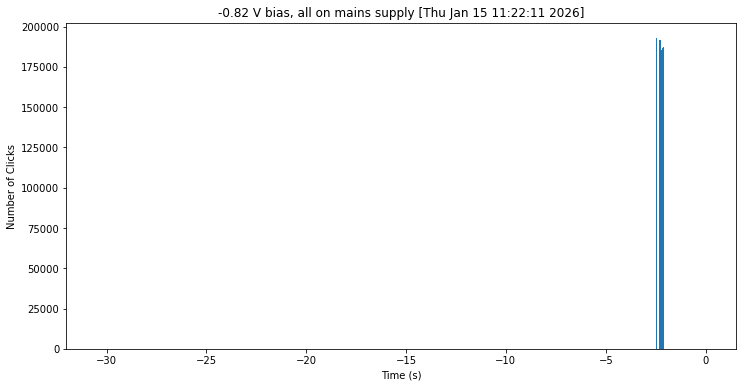

Average counts per bin: 1894.604


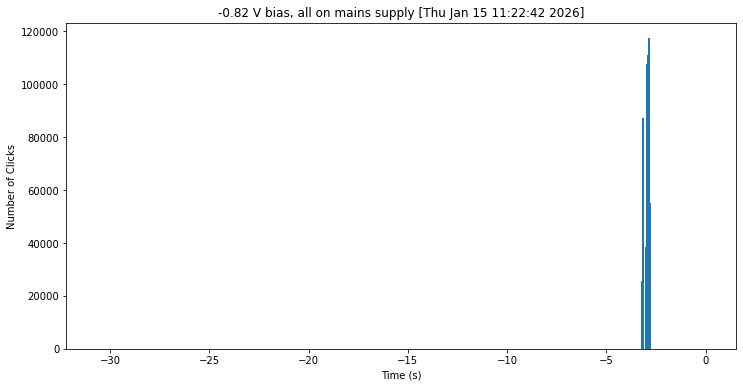

Average counts per bin: 1091.408


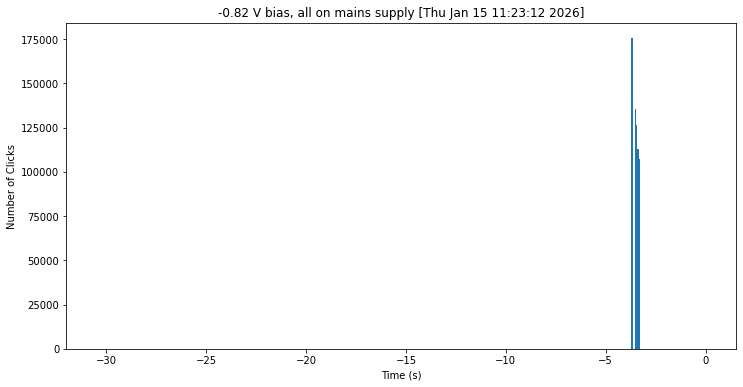

Average counts per bin: 1322.048


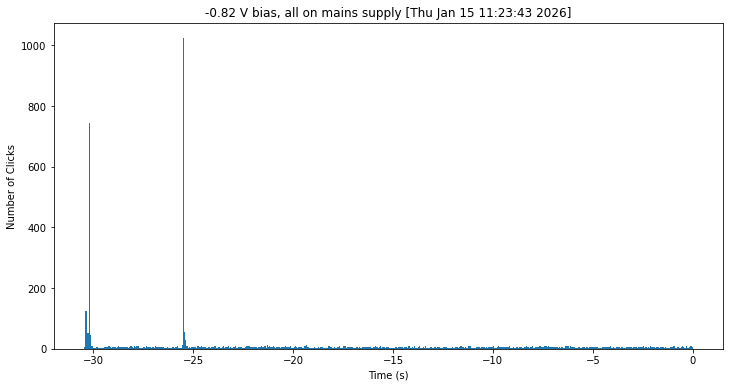

Average counts per bin: 9.674


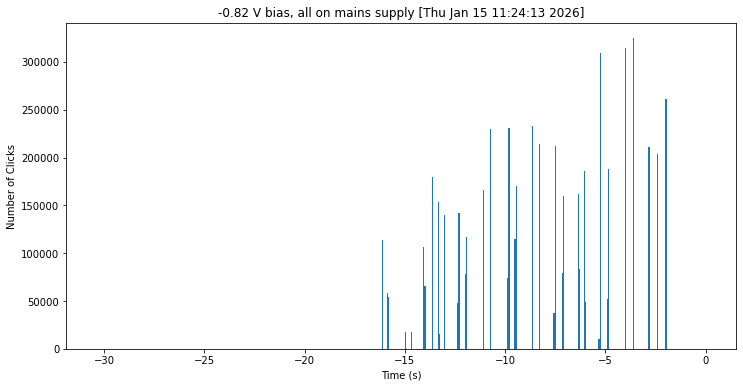

Average counts per bin: 11171.306


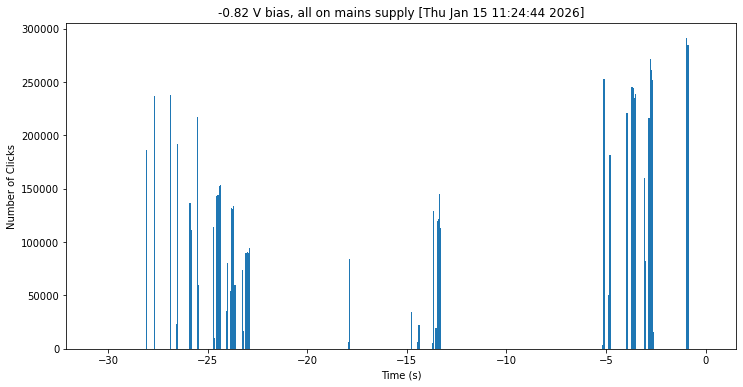

Average counts per bin: 15034.598


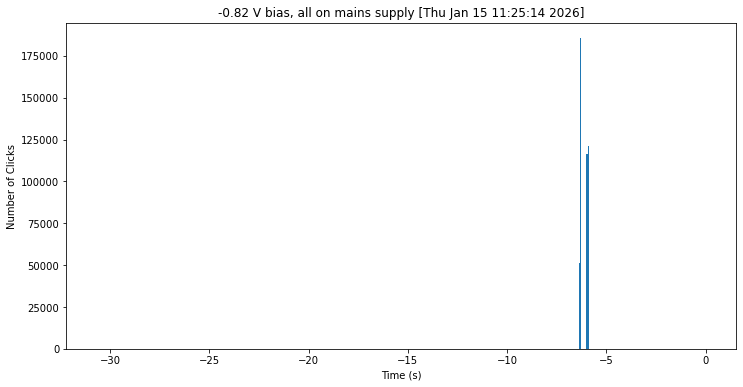

Average counts per bin: 954.436


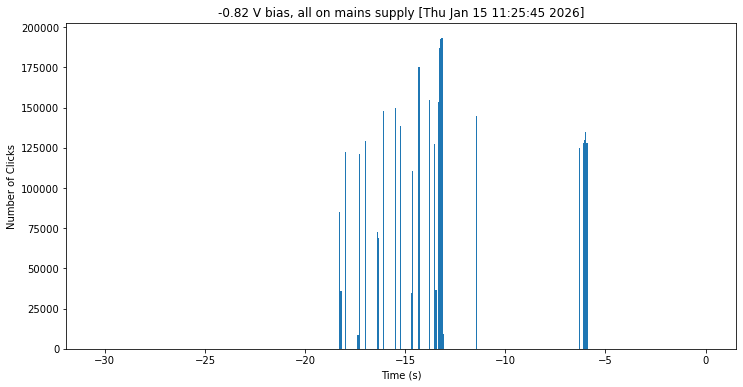

Average counts per bin: 6496.662


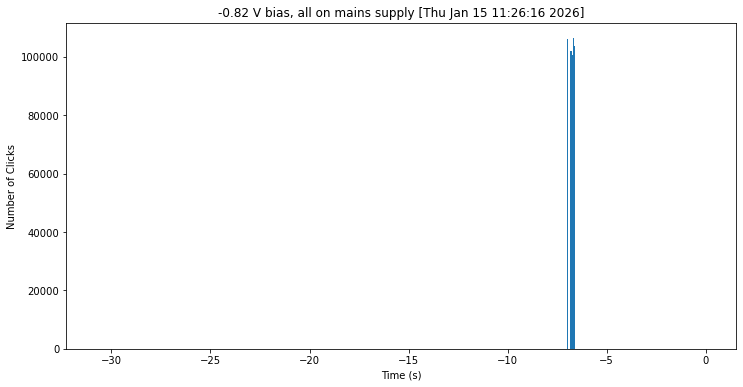

Average counts per bin: 1042.952


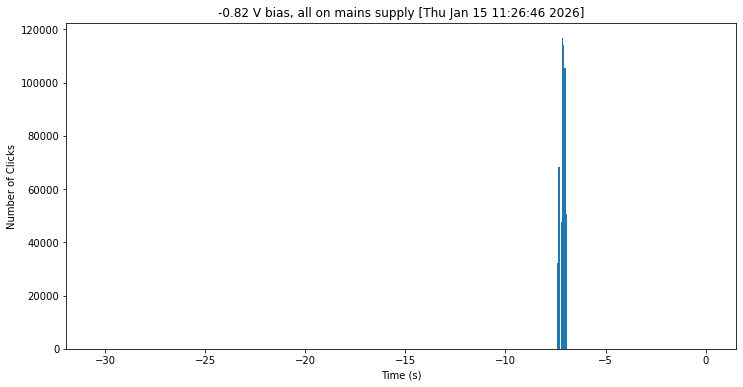

Average counts per bin: 1075.706


In [65]:
# Measure every 30s for 5 minutes at 0V, all mains
bias = -0.82
exhp.reset_detector(detectorOut, bias, sleepTime = 0.5)
print(fr'SNSPD bias current: {exhp.get_detector_current(dmm)*1e6} uA')

startTime = 0 * ps
while startTime < 310 * ps:
    captureTags(ttStream, bias)
    time.sleep(30)
    startTime += 30 * ps

### Switching

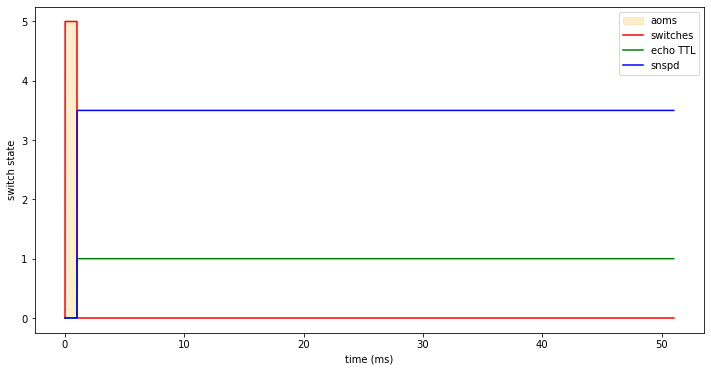

In [59]:
exhp.set_up_echo_SNSPD(awg, 0, 1e3, 1, countFor = 50e3, switchPreDelay = 0, plotting = True)

In [124]:
exhp.set_up_echo_SNSPD(awg, 0, 1e3, 1, countFor = 50e3, switchPreDelay = 0, plotting = False)
exhp.set_deadcycles(awg, 1, [1,2,3,4])


In [121]:
exhp.all_on(awg)

### Counting

In [20]:
exhp.set_up_echo_SNSPD(awg, 0, 1e3, 1, countFor = 50e3, switchPreDelay = 0, plotting = False)
exhp.set_deadcycles(awg, 2, [1,2,3,4])

SNSPD bias current: 5.095896 uA


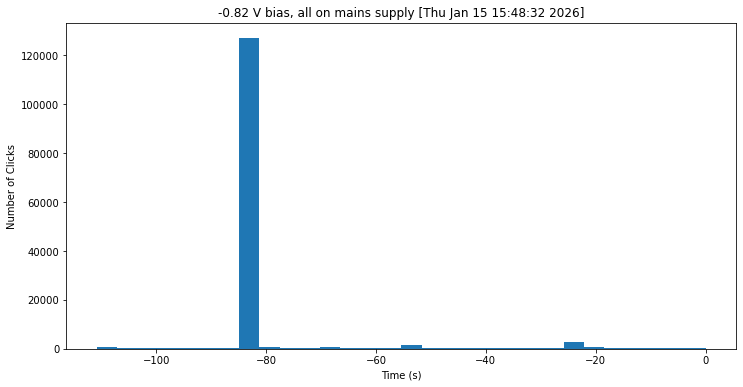

Missed counts since last data retrieval: 18
Average counts per bin: 288.544


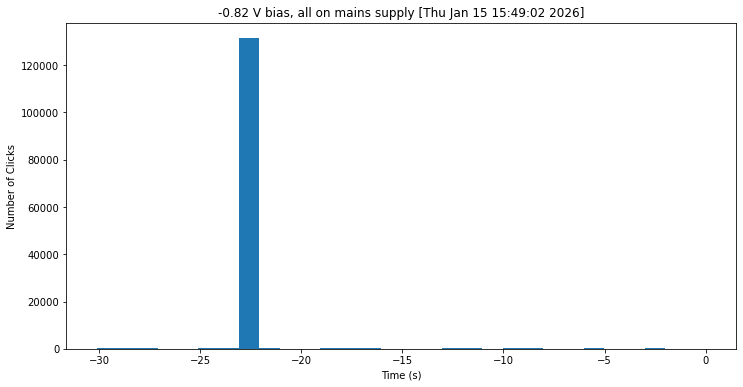

Missed counts since last data retrieval: 18
Average counts per bin: 270.094


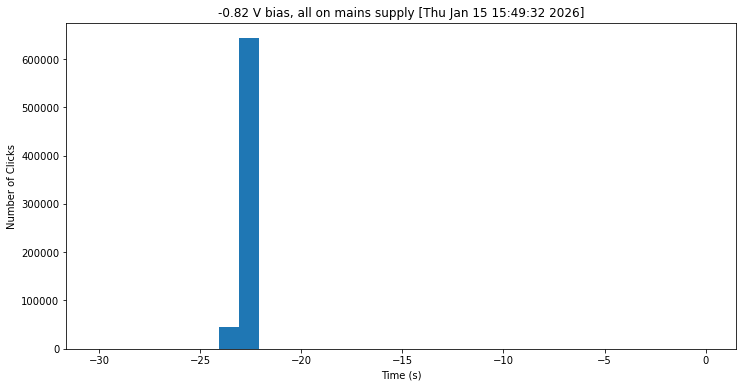

Missed counts since last data retrieval: 32
Average counts per bin: 1383.72


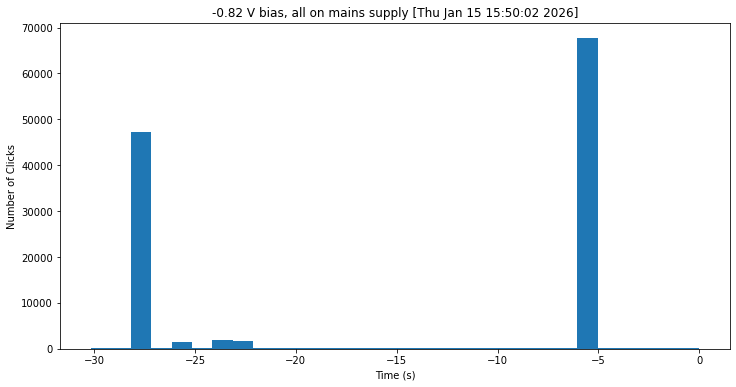

Missed counts since last data retrieval: 21
Average counts per bin: 245.972


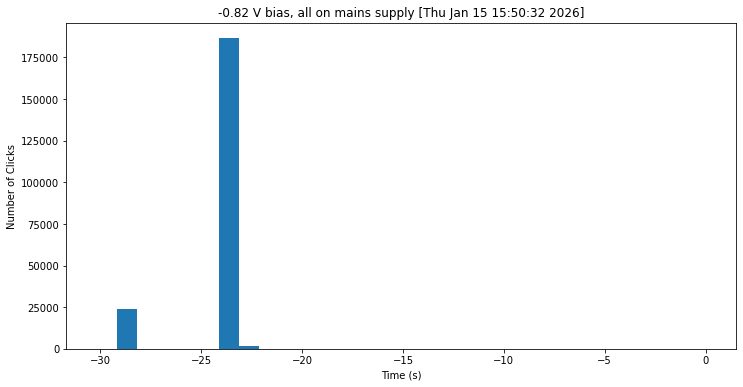

Missed counts since last data retrieval: 20
Average counts per bin: 431.06


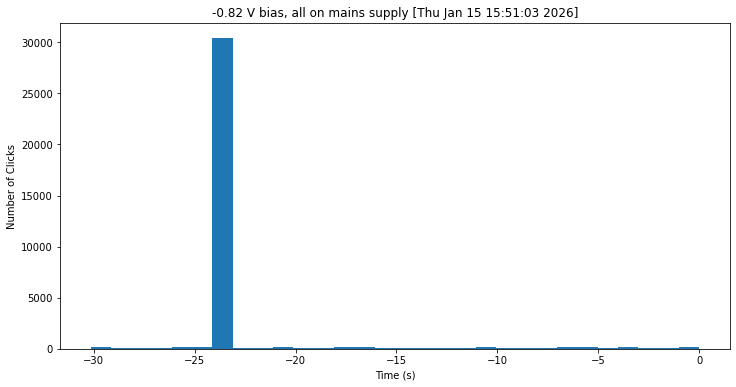

Missed counts since last data retrieval: 11
Average counts per bin: 67.94


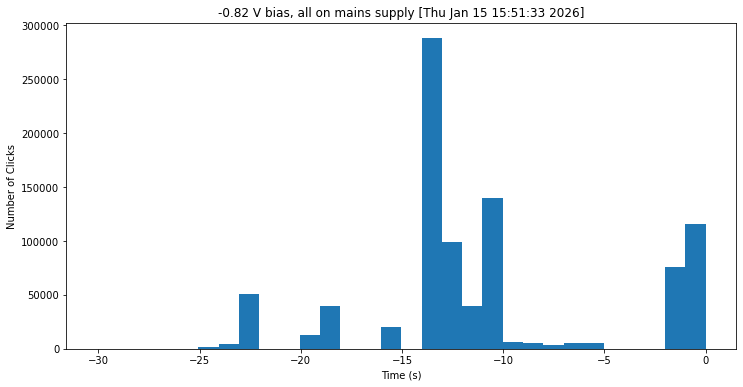

Missed counts since last data retrieval: 25
Average counts per bin: 1831.372


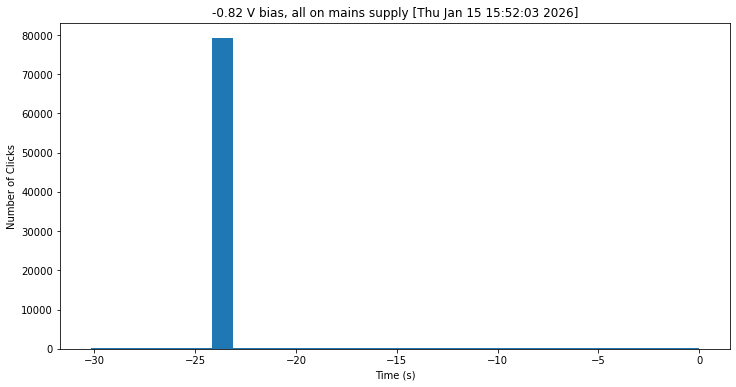

Missed counts since last data retrieval: 19
Average counts per bin: 165.51


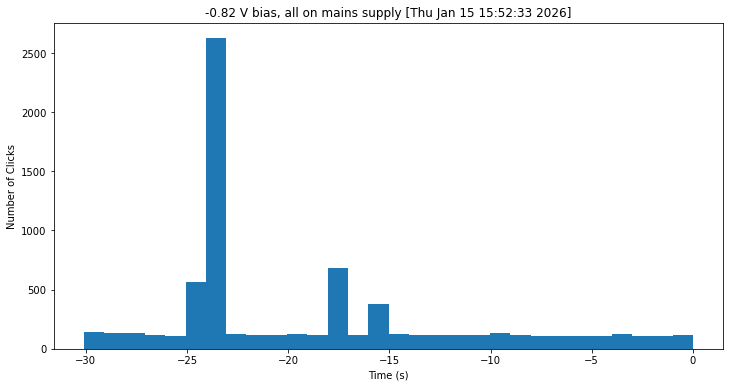

Missed counts since last data retrieval: 13
Average counts per bin: 14.682


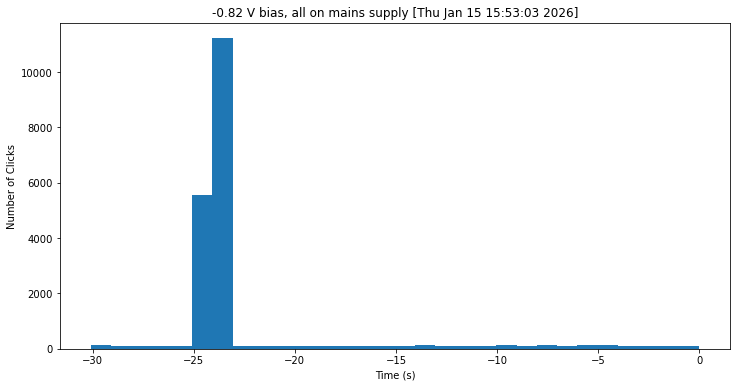

Missed counts since last data retrieval: 14
Average counts per bin: 40.004


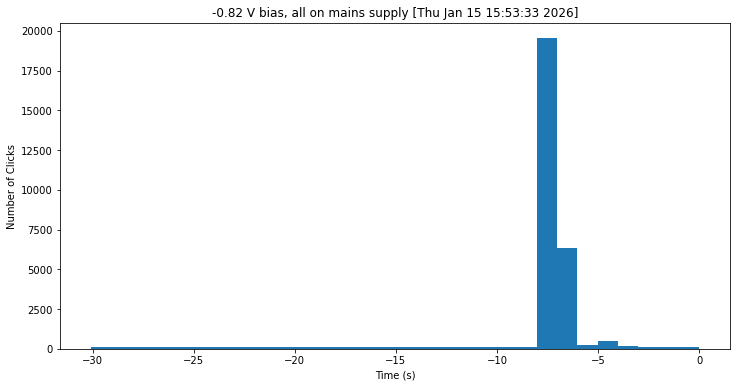

Missed counts since last data retrieval: 15
Average counts per bin: 59.594


In [46]:
# Measure every 30s for 5 minutes at 0V, all mains
bias = -0.82
exhp.reset_detector(detectorOut, bias, sleepTime = 0.5)
print(fr'SNSPD bias current: {exhp.get_detector_current(dmm)*1e6} uA')

startTime = 0 * ps
while startTime < 310 * ps:
    time.sleep(30)
    captureTags(ttStream, bias, 30)
    startTime += 30 * ps

# 16/01
Track noise from 8:45-10:45am.. okay so it only ran for 7 minutes lol.

In [ ]:
### Swabian timetagger
import TimeTagger
tt = TimeTagger.createTimeTagger()
ps = 1e12 # [ps/s] - picoseconds per second 
binWidth = 5e-5 * ps  
nBins = 1e4 # number of bins

# Channel setup
tt.setTriggerLevel(1, 0.03) # click channel trigger level = 30 mV
tt.setDeadtime(1, 50e-9 * ps) # 50 ns dead time 
tt.setTriggerLevel(2, 0.25) # starts channel trigger level = 250 mV (signal is 500 mV)
tt.setDeadtime(2, 5e-9 * ps) # 5 ns dead time

ttStream = TimeTagger.TimeTagStream(tagger = tt, 
                                    n_max_events = 1e9, 
                                    channels = [1]) 
hist = TimeTagger.Histogram(tagger = tt, 
                            start_channel = 2, 
                            click_channel = 1, 
                            binwidth = binWidth, 
                            n_bins = nBins)

In [96]:
def captureTags(ttStream, bias, duration, bins, plot, save, plotPath, dataPath):
    ps = 1e12 # [ps/s] - picoseconds per second 
    ttLive = ttStream.getData()
    localTime = time.localtime()
    timestamp = time.strftime('%Y%m%d_%H%M%S', localTime)
    ttTimes = ttLive.getTimestamps()

    if plot or save:
        plt.figure(figsize = (12, 6))
        plt.hist((ttTimes - np.max(ttTimes))/ps, bins = bins)
        plt.xlabel('Time since last click (s)') # I am not convinced...
        plt.ylabel('Number of Clicks')
        plt.title(fr'{bias} V bias, all on mains supply [{time.asctime(localTime)}]')

        if save ==True:
            counts, binEdges = np.histogram(ttTimes, bins = bins) # absolute times here in ps
            data = np.column_stack((binEdges[:-1], counts))
            np.savetxt(os.path.join(dataPath, f'{timestamp} at {bias} V.csv'),
                        data,
                        delimiter = ',',
                        header = 'Absolute time since start stream (ps), Counts')                    
            plt.savefig(os.path.join(plotPath, f'{timestamp} at {bias} V.png'),
            dpi = 200,
            bbox_inches = 'tight')

        if plot == True:
            plt.show()
        
        else: 
            plt.close()

    # Bin with counts per second for consistency with time tagger GUI
    binnedInSeconds = np.histogram(ttTimes / ps, bins = duration) # absoliute times here
    countsBySecond = binnedInSeconds[0]

    print(fr'Missed counts since last data retrieval: {ttStream.getCounts()}')
    print(fr'Average counts per second: {np.average(countsBySecond)}')

    return

In [86]:
plotPath = r'plots/2026-01-16/dark counts'
dataPath = r'data/2026-01-16/dark counts'

duration = 60
bins = 500

In [97]:
# Measure every 30s for 2 hours at 0V, all (rigols and stahl) on UPS
bias = 0
exhp.reset_detector(detectorOut, bias, sleepTime = 0.5)
print(fr'SNSPD bias current: {exhp.get_detector_current(dmm)*1e6} uA')

startTime = 0 * ps
while startTime < 7200 * ps:
    captureTags(ttStream, bias, duration = 60, bins = 500, 
                plot = False, save = True, 
                plotPath = plotPath, dataPath = dataPath)
    time.sleep(duration)
    startTime += duration * ps

SNSPD bias current: 0.002524695 uA
Missed counts since last data retrieval: 29
Average counts per second: 5.5
Missed counts since last data retrieval: 17
Average counts per second: 691.7833333333333
Missed counts since last data retrieval: 9
Average counts per second: 102.25
Missed counts since last data retrieval: 15
Average counts per second: 248.03333333333333
Missed counts since last data retrieval: 11
Average counts per second: 109.88333333333334
Missed counts since last data retrieval: 299
Average counts per second: 114.05
Missed counts since last data retrieval: 25
Average counts per second: 133.35


MemoryError: bad allocation

### Efficiency Testing
done on '20251027 SNSPD Efficiency.ipynb'.

# 19/01 OOR Measurements

In [141]:
### For the Moku Pro
from moku.instruments import ArbitraryWaveformGenerator
mokuIP = '10.196.50.45' # Sydnet6 IP for Moku Pro
awg = ArbitraryWaveformGenerator(mokuIP, force_connect=True, persist_state=True, read_timeout=30)

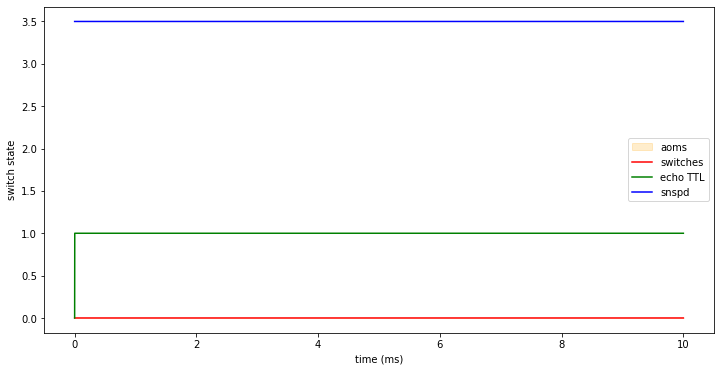

In [178]:
# ALL OOMs ON
exhp.set_up_echo_SNSPD(awg, 0, 0, 0, 0, countFor = 10e3, plotting = True)
exhp.set_up_echo_SNSPD(awg, 0, 0, 0, 0, countFor = 10e3, plotting = False)
exhp.set_deadcycles(awg, 1, (1, 2, 3, 4))

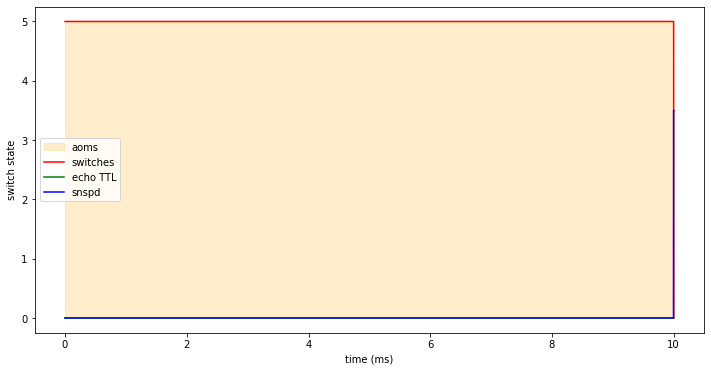

In [179]:
# ALL FOSs, AOMs ON
exhp.set_up_echo_SNSPD(awg, 0, 10e3, 0, 0, countFor = 0, plotting = True)
exhp.set_up_echo_SNSPD(awg, 0, 10e3, 0, 0, countFor = 0, plotting = False)
exhp.set_deadcycles(awg, 1, (1, 2, 3, 4))

In [168]:
exhp.all_on(awg)

# Free Instruments

In [213]:
TimeTagger.freeTimeTagger(tt)

False

In [214]:
stahl.close()
dmm.close()